# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.common.utils import get_root_directory
from src.common.plotter import Plotter
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import calendar
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
import gensim
from gensim.utils import simple_preprocess
from src.sentiment_analyser.bert_sentiment_analyser import BertSentimentAnalyser
from src.sentiment_analyser.vader_sentiment_analyser import VaderSentimentAnalyser

## Google News Headlines

In [2]:
root_dir = get_root_directory()
plotter = Plotter(root_dir)
processed_gn = pd.read_csv(f"{root_dir}\\data\\final\\sentiment_analysis.csv")

In [3]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   156574 non-null  object 
 1   News Headline          156574 non-null  object 
 2   Publisher              156574 non-null  object 
 3   D_VADER_Score          156574 non-null  float64
 4   D_VADER_Sent           156574 non-null  int64  
 5   D_FINBERT_ConScore     156574 non-null  float64
 6   D_FINBERT_Sent         156574 non-null  int64  
 7   D_CRYPTOBERT_ConScore  156574 non-null  float64
 8   D_CRYPTOBERT_Sent      156574 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 10.8+ MB


In [4]:
index = processed_gn.loc[processed_gn["Date"]=="2024-04-01"].index

In [5]:
processed_gn = processed_gn.loc[:max(index)]

In [6]:
processed_gn['Date'] = pd.to_datetime(processed_gn['Date'])

In [7]:
publishers = list(processed_gn['Publisher'].unique())

In [8]:
len(publishers)

7223

In [9]:
headlines = list(processed_gn['News Headline'].unique()) 

In [10]:
len(headlines)

134135

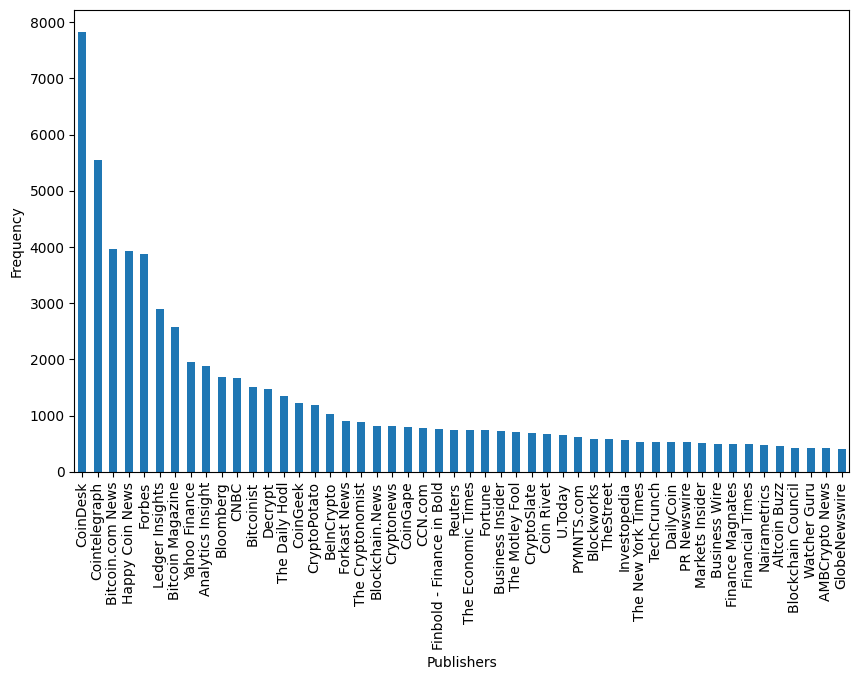

In [12]:
n = 50
top_n = processed_gn['Publisher'].value_counts().nlargest(n)
plotter = Plotter(root_dir)
plotter.plot_barchart(df=top_n, x="Publishers", y="Frequency")

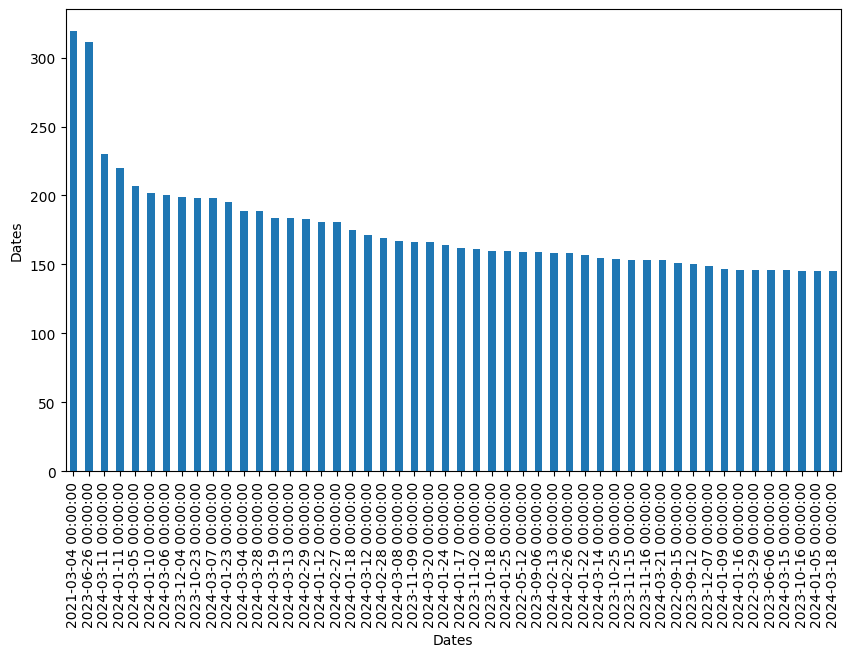

In [13]:
n = 50
top_n = processed_gn['Date'].value_counts().nlargest(n)
plotter.plot_barchart(df=top_n, x="Dates", y="Dates")

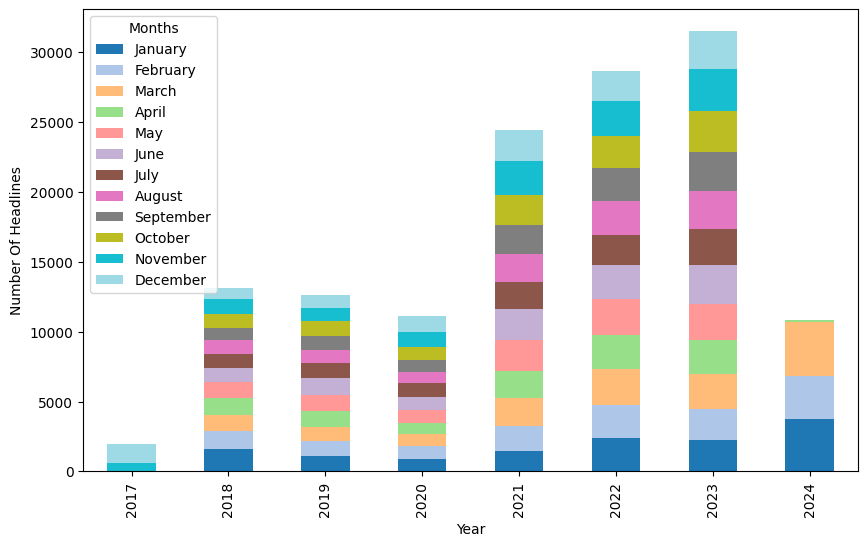

In [14]:
processed_gn['year'] = processed_gn['Date'].dt.year
processed_gn['month'] =processed_gn['Date'].dt.month
processed_gn['month_name'] = processed_gn['Date'].dt.month_name()
grouped = processed_gn.groupby(['year', 'month_name']).size().unstack(fill_value=0)
months_order = list(calendar.month_name)[1:] 
grouped = grouped.reindex(columns=months_order, fill_value=0)
grouped
plotter.plot_barchart(df=grouped, x="year", y="Number of Headlines", legend="Months", colormap="tab20",stacked=True)

In [14]:
plotter.save_graph()

TypeError: Plotter.save_graph() missing 1 required positional argument: 'filepath'

In [15]:
processed_gn['length'] = processed_gn['News Headline'].apply(lambda x: len(x.split()))

In [16]:
extreme = list(processed_gn['News Headline'][processed_gn['length']==46])

In [17]:
processed_gn.describe()

,Date,D_VADER_Score,D_VADER_Sent,D_FINBERT_ConScore,D_FINBERT_Sent,D_CRYPTOBERT_ConScore,D_CRYPTOBERT_Sent,year,month,length
count,134135,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000,134135.000000
mean,2021-10-11 10:51:45.605546496,0.054286,0.134119,0.831877,0.013203,0.697649,0.168554,2021.299795,6.270295,13.148686
min,2017-11-09 00:00:00,-0.944200,-1.000000,0.336737,-1.000000,0.337411,-1.000000,2017.000000,1.000000,3.000000
25%,2020-07-16 00:00:00,0.000000,0.000000,0.774887,0.000000,0.570274,0.000000,2020.000000,3.000000,11.000000
50%,2022-02-16 00:00:00,0.000000,0.000000,0.882624,0.000000,0.671197,0.000000,2022.000000,6.000000,13.000000
75%,2023-04-22 00:00:00,0.258400,1.000000,0.925166,0.000000,0.821149,0.000000,2023.000000,9.000000,15.000000
max,2024-04-01 00:00:00,0.957800,1.000000,0.976155,1.000000,0.996783,1.000000,2024.000000,12.000000,46.000000
std,NaN,0.322609,0.699539,0.123792,0.476892,0.150100,0.429486,1.833964,3.567612,3.454540


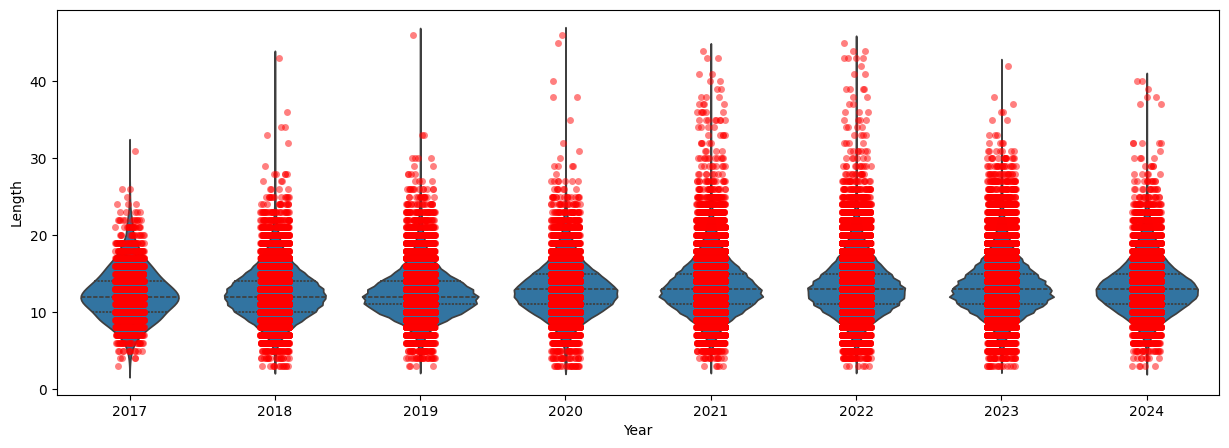

In [18]:
plotter.plot_violin_plot(df=processed_gn, x="year", y="length", stripplot = True, figsize=(15,5))

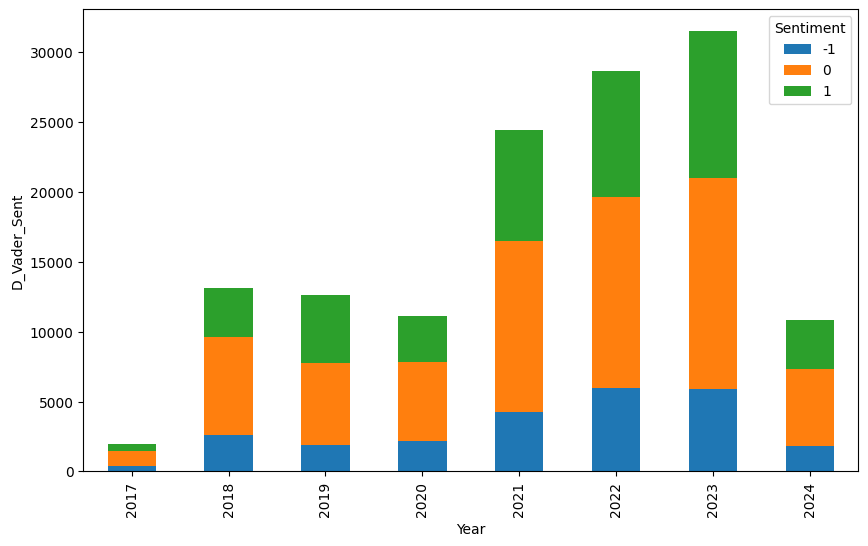

In [19]:
grouped = processed_gn.groupby(['year', 'D_VADER_Sent']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent", legend="Sentiment", stacked=True)
# plotter.save_graph()

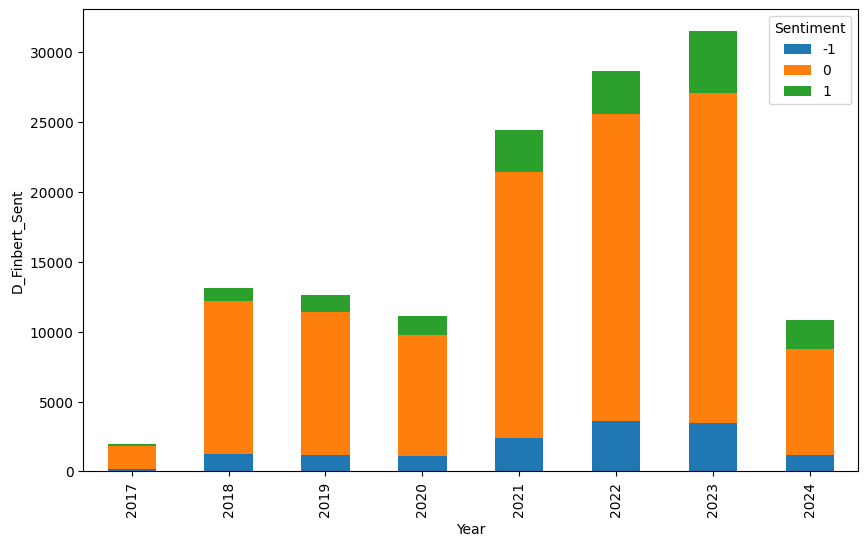

In [20]:
grouped = processed_gn.groupby(['year', 'D_FINBERT_Sent']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_FINBERT_Sent", legend="Sentiment", stacked=True)
# plotter.save_graph()

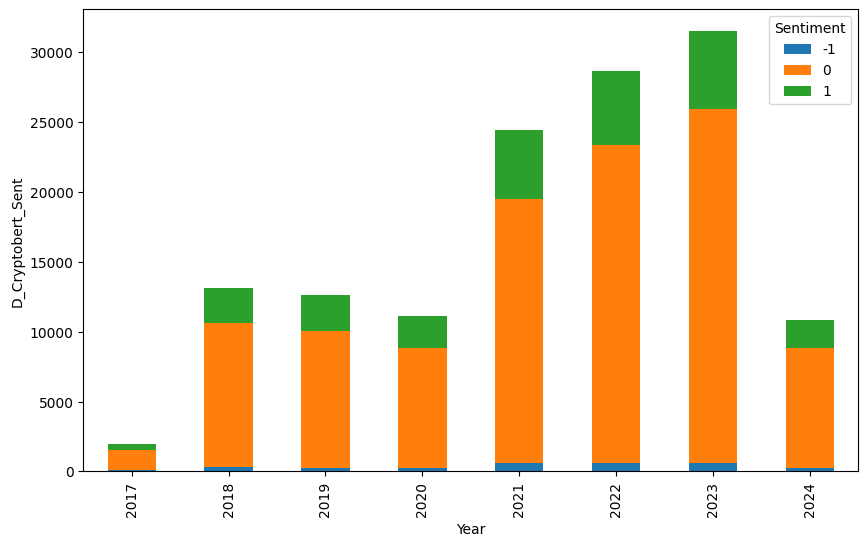

In [21]:
grouped = processed_gn.groupby(['year', 'D_CRYPTOBERT_Sent']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_CRYPTOBERT_Sent", legend="Sentiment", stacked=True)
# plotter.save_graph()

In [250]:
keywords = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
# keywords = ['cointelegraph']
pattern = '|'.join(keywords)
processed_gn_coin = processed_gn[processed_gn["Publisher"].str.contains(pattern, case=True, na=False)]
# processed_gn_coin = processed_gn

In [251]:
print(list(processed_gn_coin["Publisher"].unique()))

['Cointelegraph', 'CoinDesk', 'GCU Today', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today', 'The Block Talk', 'The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks', 'EU Today', 'br.cointelegraph.com']


In [23]:
VADER_AvgScr_In = processed_gn.pivot_table(values="D_VADER_Score", index=["Date"], aggfunc="mean")

In [24]:
VADER_AvgScr_In.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   D_VADER_Score  2336 non-null   float64
dtypes: float64(1)
memory usage: 36.5 KB


In [25]:
Features = VADER_AvgScr_In.rename(columns={"D_VADER_Score":"D_VADER_AvgScr_In"})

In [26]:
import swifter
def determine_score_sentiment(input_var:float)->int:
    if not isinstance(input_var, float):
        raise ValueError("Input must be a float")
    if input_var >= 0.05:
        return 1
    elif input_var <= -0.05:
        return -1
    else:
        return 0
    

In [27]:
Features["D_VADER_Sent_AvgIn"] = Features['D_VADER_AvgScr_In'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [30]:
dropped_neutrals = processed_gn.drop(processed_gn[processed_gn['D_VADER_Sent'] == 0].index)

In [31]:
VADER_AvgScr_Ex = dropped_neutrals.pivot_table(values="D_VADER_Score", index=["Date"], aggfunc="mean")

In [32]:
VADER_AvgScr_Ex.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   D_VADER_Score  2336 non-null   float64
dtypes: float64(1)
memory usage: 36.5 KB


In [33]:
Features["D_VADER_AvgScr_Ex"] = VADER_AvgScr_Ex["D_VADER_Score"]
Features["D_VADER_Sent_AvgEx"] = Features['D_VADER_AvgScr_Ex'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [34]:
Features

,D_VADER_AvgScr_In,D_VADER_Sent_AvgIn,D_VADER_AvgScr_Ex,D_VADER_Sent_AvgEx
Date,,,,
2017-11-09,0.082633,1,0.202827,1
2017-11-10,0.189088,1,0.267875,1
2017-11-11,0.065342,1,0.112014,1
2017-11-12,0.037093,0,0.088433,1
2017-11-13,0.036083,0,0.078931,1
...,...,...,...,...
2024-03-28,0.019836,0,0.037374,0
2024-03-29,0.058162,1,0.118291,1
2024-03-30,0.075112,1,0.187781,1


In [35]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134135 entries, 0 to 134134
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   134135 non-null  datetime64[ns]
 1   News Headline          134135 non-null  object        
 2   Publisher              134135 non-null  object        
 3   D_VADER_Score          134135 non-null  float64       
 4   D_VADER_Sent           134135 non-null  int64         
 5   D_FINBERT_ConScore     134135 non-null  float64       
 6   D_FINBERT_Sent         134135 non-null  int64         
 7   D_CRYPTOBERT_ConScore  134135 non-null  float64       
 8   D_CRYPTOBERT_Sent      134135 non-null  int64         
 9   year                   134135 non-null  int32         
 10  month                  134135 non-null  int32         
 11  month_name             134135 non-null  object        
 12  length                 134135 non-null  int6

In [37]:
processed_gn["D_FINBERT_AvgScr_In"] = processed_gn["D_FINBERT_ConScore"]*processed_gn["D_FINBERT_Sent"]
dropped_neutrals = processed_gn.drop(processed_gn[processed_gn['D_FINBERT_Sent'] == 0].index)
dropped_neutrals["D_FINBERT_AvgScr_Ex"] = dropped_neutrals["D_FINBERT_ConScore"]*dropped_neutrals["D_FINBERT_Sent"]

In [38]:
FINBERT_AvgScr_In = processed_gn.pivot_table(values="D_FINBERT_AvgScr_In", index=["Date"], aggfunc="mean")
FINBERT_AvgScr_Ex = dropped_neutrals.pivot_table(values="D_FINBERT_AvgScr_Ex", index=["Date"], aggfunc="mean")

In [39]:
FINBERT_AvgScr_Ex.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2316 entries, 2017-11-09 to 2024-04-01
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   D_FINBERT_AvgScr_Ex  2316 non-null   float64
dtypes: float64(1)
memory usage: 36.2 KB


In [40]:
Features["D_FINBERT_AvgScr_In"] = FINBERT_AvgScr_In["D_FINBERT_AvgScr_In"]
Features["D_FINBERT_Sent_AvgIn"] = Features['D_FINBERT_AvgScr_In'].swifter.apply(determine_score_sentiment)
Features["D_FINBERT_AvgScr_Ex"] = FINBERT_AvgScr_Ex["D_FINBERT_AvgScr_Ex"]
Features["D_FINBERT_Sent_AvgEx"] = Features['D_FINBERT_AvgScr_Ex'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [41]:
Features.index

DatetimeIndex(['2017-11-09', '2017-11-10', '2017-11-11', '2017-11-12',
               '2017-11-13', '2017-11-14', '2017-11-15', '2017-11-16',
               '2017-11-17', '2017-11-18',
               ...
               '2024-03-23', '2024-03-24', '2024-03-25', '2024-03-26',
               '2024-03-27', '2024-03-28', '2024-03-29', '2024-03-30',
               '2024-03-31', '2024-04-01'],
              dtype='datetime64[ns]', name='Date', length=2336, freq=None)

In [42]:
import numpy as np
Features.replace(np.nan, 0, inplace=True)

In [43]:
Features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   D_VADER_AvgScr_In     2336 non-null   float64
 1   D_VADER_Sent_AvgIn    2336 non-null   int64  
 2   D_VADER_AvgScr_Ex     2336 non-null   float64
 3   D_VADER_Sent_AvgEx    2336 non-null   int64  
 4   D_FINBERT_AvgScr_In   2336 non-null   float64
 5   D_FINBERT_Sent_AvgIn  2336 non-null   int64  
 6   D_FINBERT_AvgScr_Ex   2336 non-null   float64
 7   D_FINBERT_Sent_AvgEx  2336 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 228.8 KB


In [44]:
processed_gn["D_CRYPTOBERT_AvgScr_In"] = processed_gn["D_CRYPTOBERT_ConScore"]*processed_gn["D_CRYPTOBERT_Sent"]
dropped_neutrals = processed_gn.drop(processed_gn[processed_gn['D_CRYPTOBERT_Sent'] == 0].index)
dropped_neutrals["D_CRYPTOBERT_AvgScr_Ex"] = dropped_neutrals["D_CRYPTOBERT_ConScore"]*dropped_neutrals["D_CRYPTOBERT_Sent"]
CRYPTOBERT_AvgScr_In = processed_gn.pivot_table(values="D_CRYPTOBERT_AvgScr_In", index=["Date"], aggfunc="mean")
CRYPTOBERT_AvgScr_Ex = dropped_neutrals.pivot_table(values="D_CRYPTOBERT_AvgScr_Ex", index=["Date"], aggfunc="mean")
Features["D_CRYPTOBERT_AvgScr_In"] = CRYPTOBERT_AvgScr_In["D_CRYPTOBERT_AvgScr_In"]
Features["D_CRYPTOBERT_Sent_AvgIn"] = Features['D_CRYPTOBERT_AvgScr_In'].swifter.apply(determine_score_sentiment)
Features["D_CRYPTOBERT_AvgScr_Ex"] = CRYPTOBERT_AvgScr_Ex["D_CRYPTOBERT_AvgScr_Ex"]
Features["D_CRYPTOBERT_Sent_AvgEx"] = Features['D_CRYPTOBERT_AvgScr_Ex'].swifter.apply(determine_score_sentiment)

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2336 [00:00<?, ?it/s]

In [45]:
Features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2336 entries, 2017-11-09 to 2024-04-01
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   D_VADER_AvgScr_In        2336 non-null   float64
 1   D_VADER_Sent_AvgIn       2336 non-null   int64  
 2   D_VADER_AvgScr_Ex        2336 non-null   float64
 3   D_VADER_Sent_AvgEx       2336 non-null   int64  
 4   D_FINBERT_AvgScr_In      2336 non-null   float64
 5   D_FINBERT_Sent_AvgIn     2336 non-null   int64  
 6   D_FINBERT_AvgScr_Ex      2336 non-null   float64
 7   D_FINBERT_Sent_AvgEx     2336 non-null   int64  
 8   D_CRYPTOBERT_AvgScr_In   2336 non-null   float64
 9   D_CRYPTOBERT_Sent_AvgIn  2336 non-null   int64  
 10  D_CRYPTOBERT_AvgScr_Ex   2331 non-null   float64
 11  D_CRYPTOBERT_Sent_AvgEx  2336 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 301.8 KB


In [46]:
Features.replace(np.nan, 0, inplace=True)

In [47]:
Features.describe()

,D_VADER_AvgScr_In,D_VADER_Sent_AvgIn,D_VADER_AvgScr_Ex,D_VADER_Sent_AvgEx,D_FINBERT_AvgScr_In,D_FINBERT_Sent_AvgIn,D_FINBERT_AvgScr_Ex,D_FINBERT_Sent_AvgEx,D_CRYPTOBERT_AvgScr_In,D_CRYPTOBERT_Sent_AvgIn,D_CRYPTOBERT_AvgScr_Ex,D_CRYPTOBERT_Sent_AvgEx
count,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000,2336.000000
mean,0.055925,0.485017,0.109182,0.593750,0.002320,0.030822,0.015684,0.050514,0.099024,0.883562,0.443815,0.963185
std,0.068034,0.601738,0.129647,0.663992,0.076212,0.696821,0.374210,0.943827,0.047273,0.328730,0.155405,0.242077
min,-0.275347,-1.000000,-0.391283,-1.000000,-0.392865,-1.000000,-0.968635,-1.000000,-0.137297,-1.000000,-0.799251,-1.000000
25%,0.012935,0.000000,0.025894,0.000000,-0.045884,0.000000,-0.225103,-1.000000,0.071853,1.000000,0.373922,1.000000
50%,0.054986,1.000000,0.114122,1.000000,0.003931,0.000000,0.019197,0.000000,0.096156,1.000000,0.473349,1.000000
75%,0.093954,1.000000,0.189217,1.000000,0.051843,1.000000,0.255738,1.000000,0.124124,1.000000,0.558445,1.000000
max,0.344369,1.000000,0.587917,1.000000,0.331525,1.000000,0.935805,1.000000,0.328282,1.000000,0.756137,1.000000


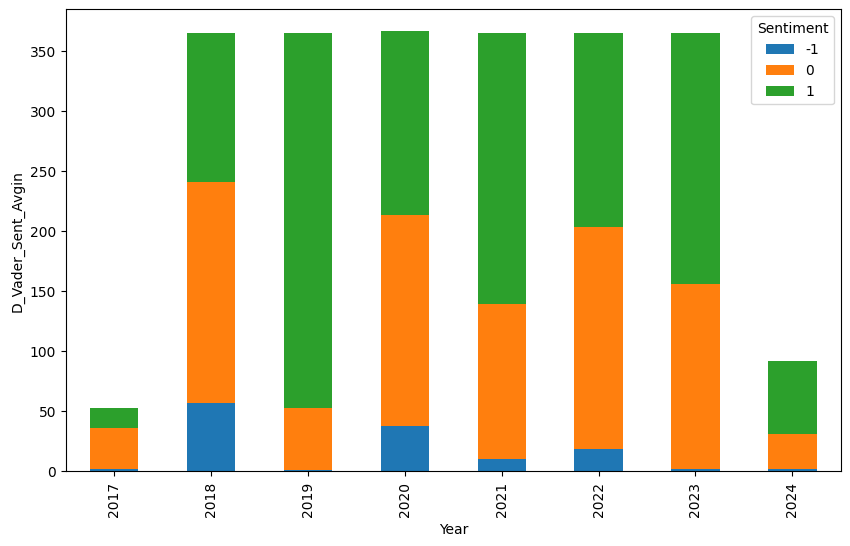

In [48]:
for_fea = Features
for_fea['year'] = for_fea.index.year
grouped = for_fea.groupby(['year', 'D_VADER_Sent_AvgIn']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent_AvgIn", legend="Sentiment", stacked=True)

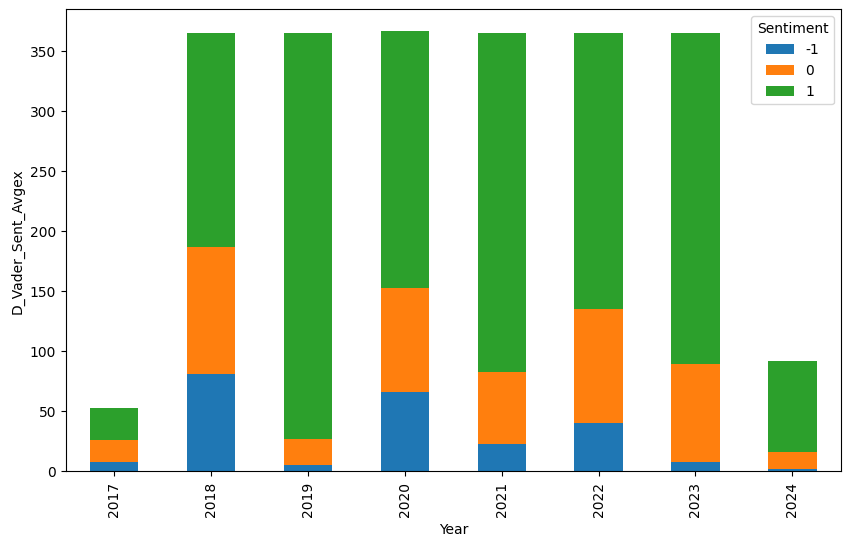

In [49]:
grouped = for_fea.groupby(['year', 'D_VADER_Sent_AvgEx']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_VADER_Sent_AvgEx", legend="Sentiment", stacked=True)

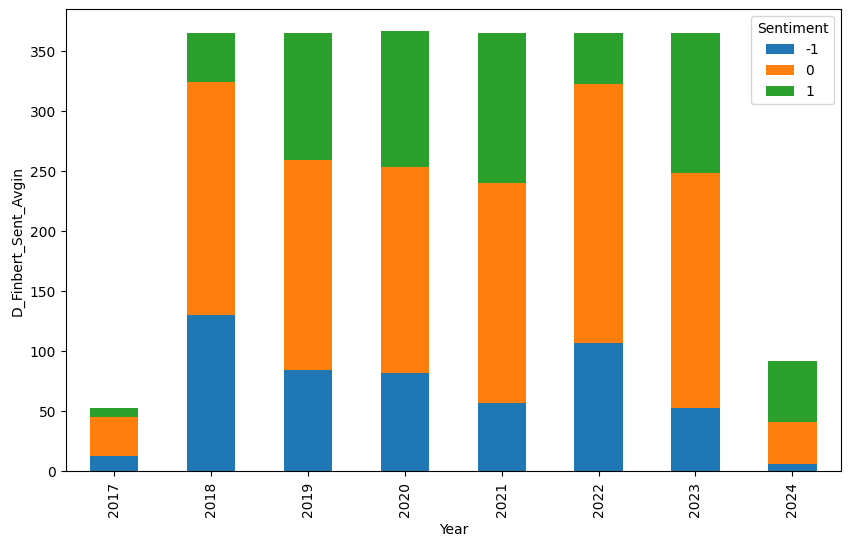

In [50]:
grouped = for_fea.groupby(['year', 'D_FINBERT_Sent_AvgIn']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_FINBERT_Sent_AvgIn", legend="Sentiment", stacked=True)

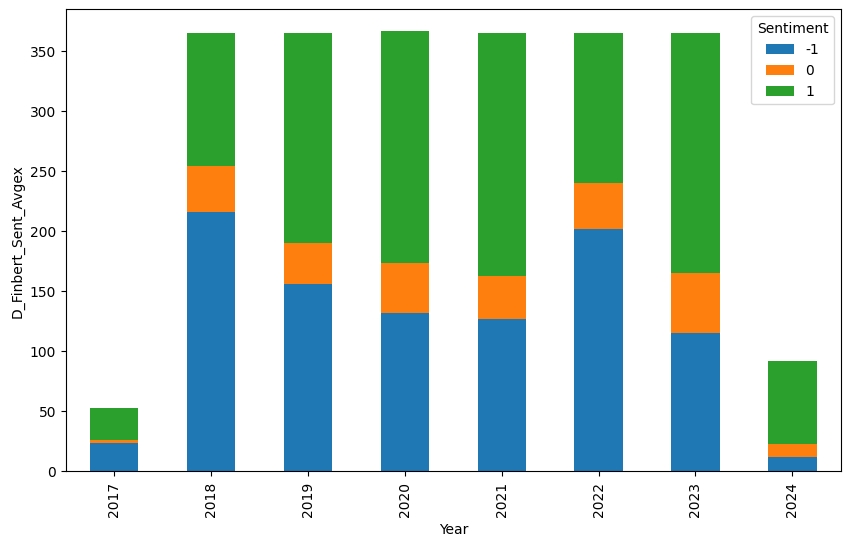

In [51]:
grouped = for_fea.groupby(['year', 'D_FINBERT_Sent_AvgEx']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_FINBERT_Sent_AvgEx", legend="Sentiment", stacked=True)

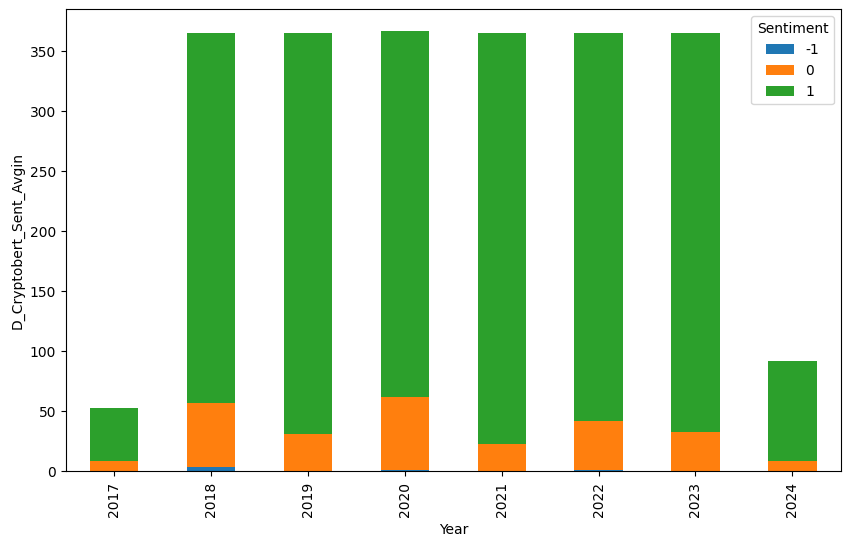

In [52]:
grouped = for_fea.groupby(['year', 'D_CRYPTOBERT_Sent_AvgIn']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_CRYPTOBERT_Sent_AvgIn", legend="Sentiment", stacked=True)

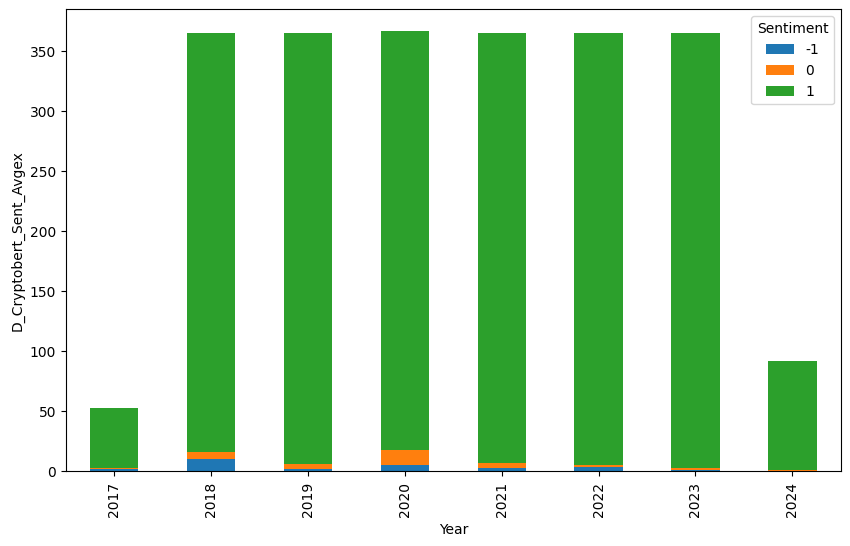

In [53]:
grouped = for_fea.groupby(['year', 'D_CRYPTOBERT_Sent_AvgEx']).size().unstack()
plotter.plot_barchart(df=grouped, x="year", y="D_CRYPTOBERT_Sent_AvgEx", legend="Sentiment", stacked=True)

## Crypto Price Data

In [54]:
eth = pd.read_csv(f"{root_dir}\\data\\final\\ETH.csv")
eth["Date"]= pd.to_datetime(eth["Date"])
eth = eth.set_index("Date")
eth.columns = [f"ETH_{col}" for col in eth.columns]
btc = pd.read_csv(f"{root_dir}\\data\\final\\BTC.csv")
btc["Date"]= pd.to_datetime(btc["Date"])
btc = btc.set_index("Date")
btc.columns = [f"BTC_{col}" for col in btc.columns]
# ltc = pd.read_csv(f"{root_dir}\\data\\final\\LTC.csv")
# ltc["Date"]= pd.to_datetime(ltc["Date"])
# ltc= ltc.set_index("Date")
# ltc.columns = [f"LTC_{col}" for col in ltc.columns]

In [62]:
all_data = pd.concat([eth, btc, Features], axis=1)
drop_columns = [col for col in all_data.columns if "YF" in col or "year" in col and "YF_Vol" not in col]
drop_columns

['ETH_YF_Op',
 'ETH_YF_Hi',
 'ETH_YF_Lo',
 'ETH_YF_Cls',
 'ETH_YF_Vol',
 'BTC_YF_Op',
 'BTC_YF_Hi',
 'BTC_YF_Lo',
 'BTC_YF_Cls',
 'BTC_YF_Vol',
 'year']

In [63]:
corr = all_data.drop(columns=drop_columns)

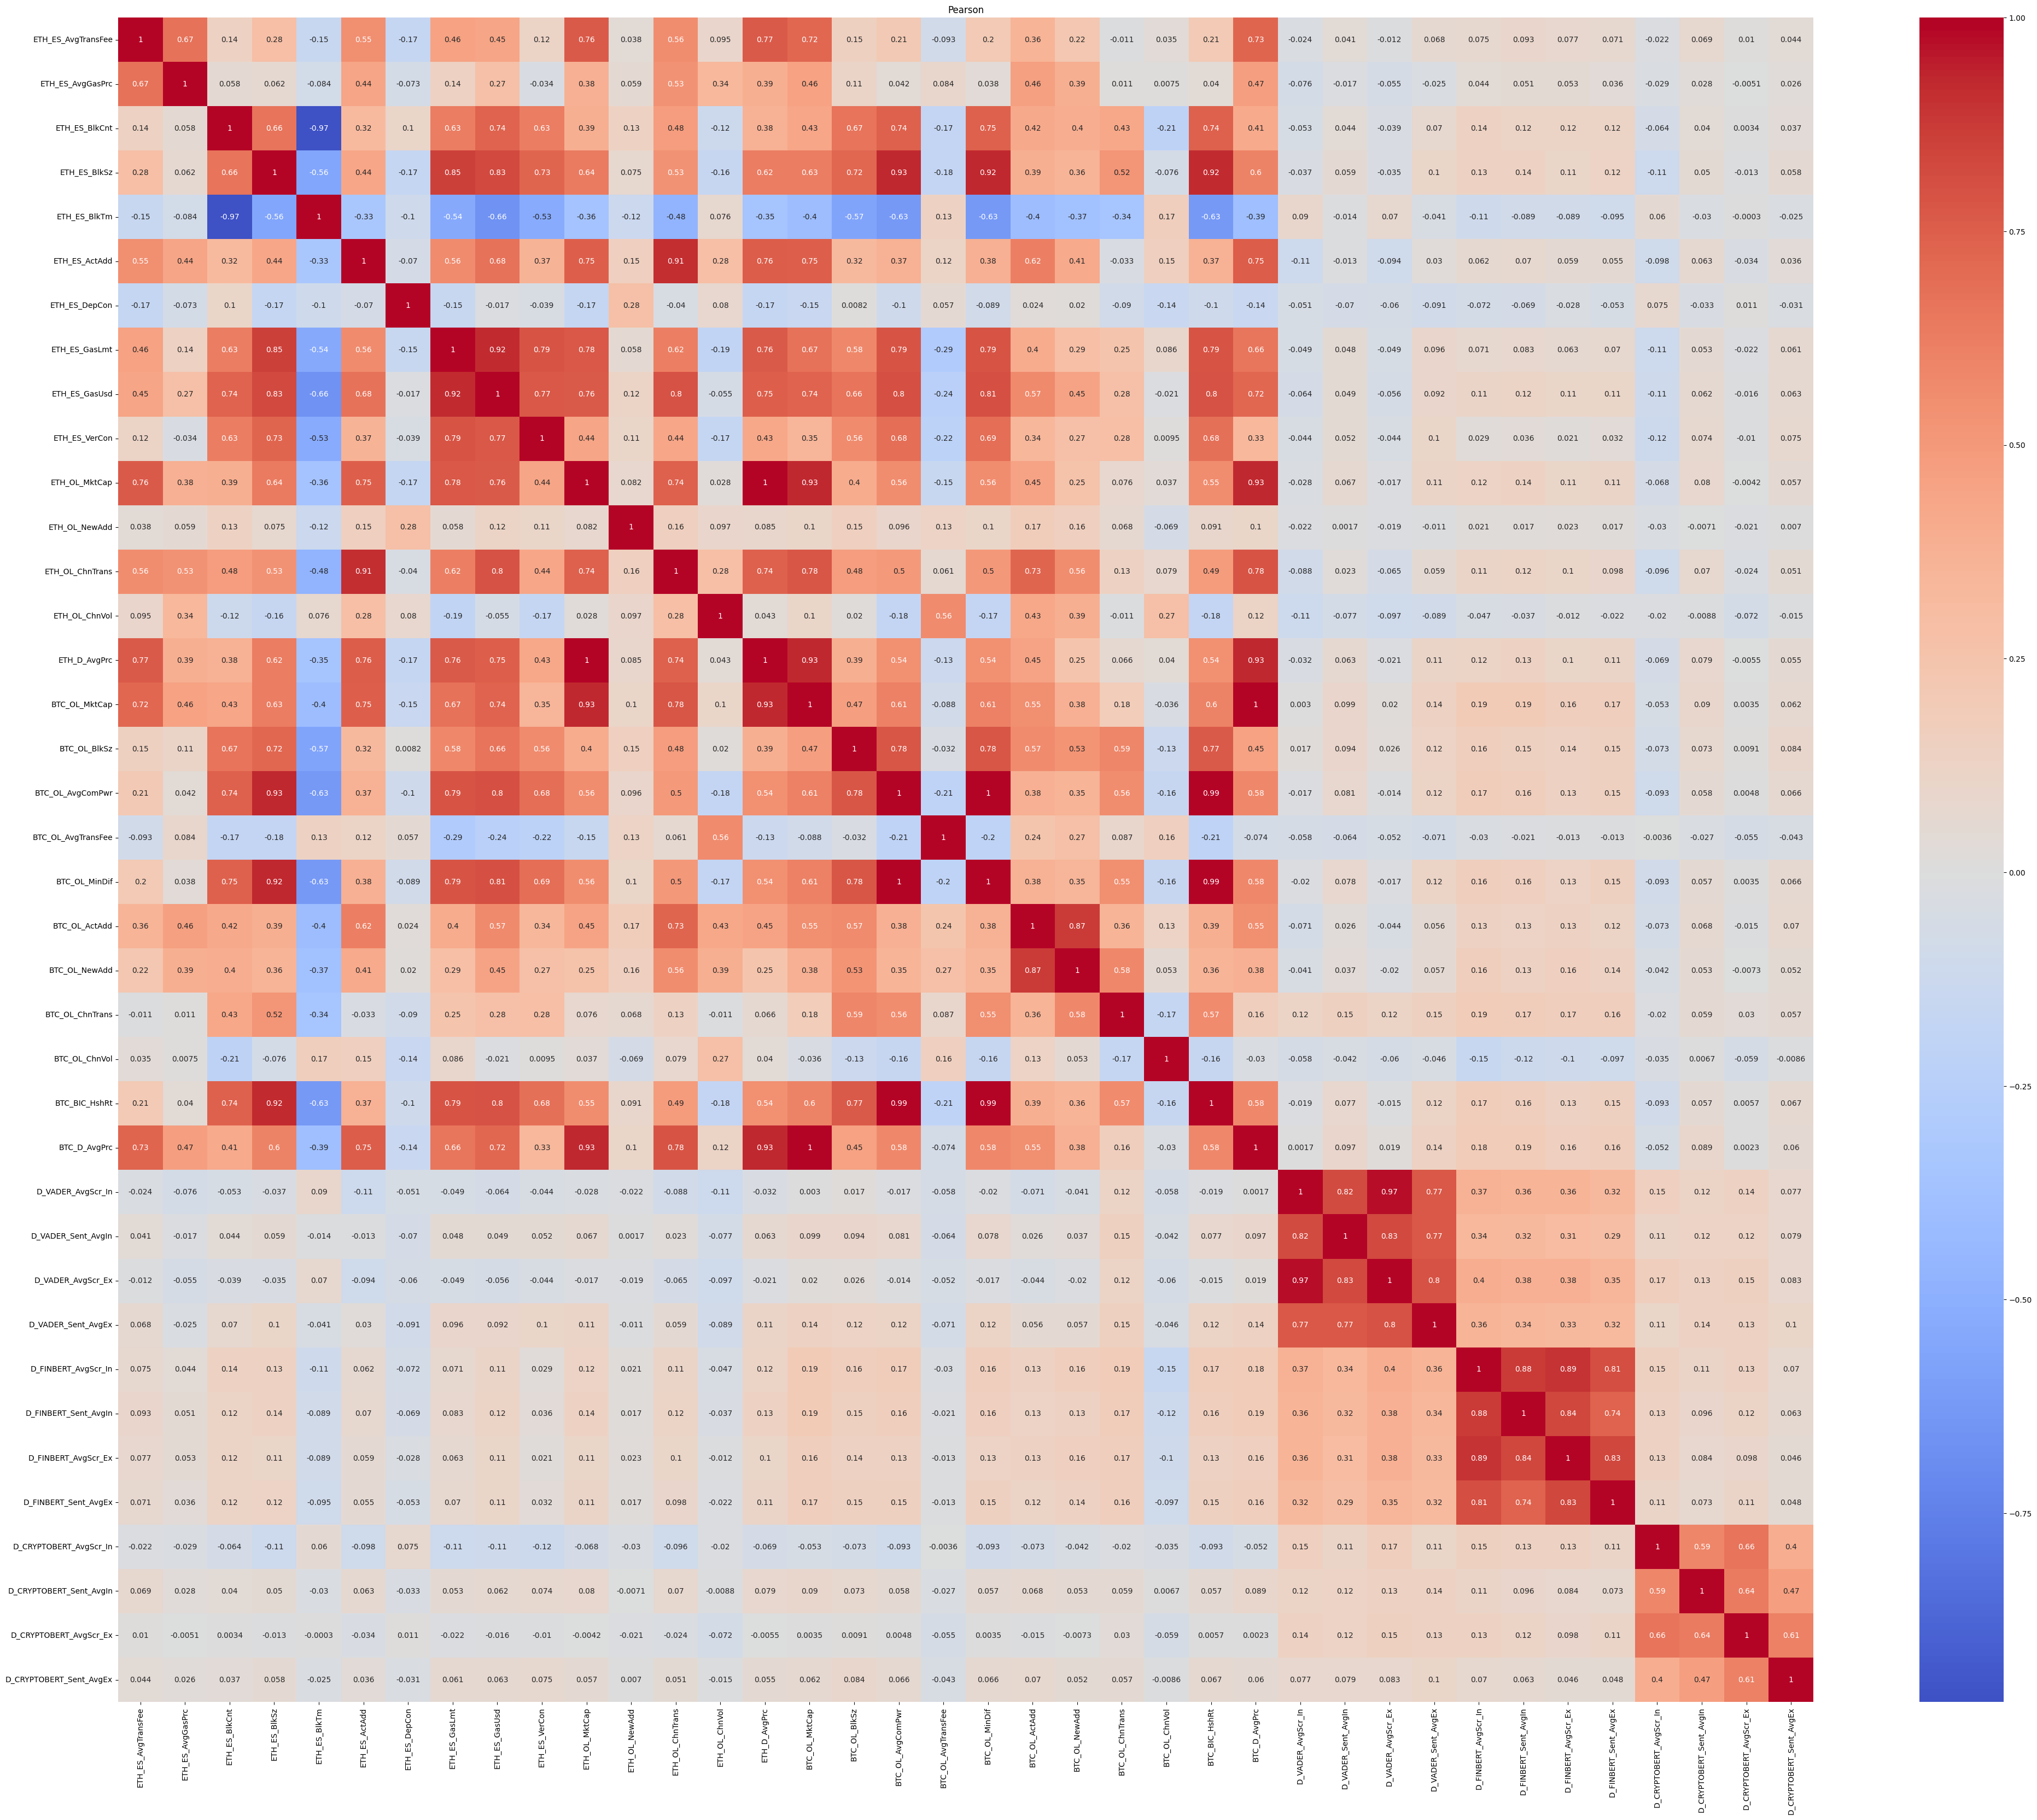

In [67]:
plotter.plot_correlation_matrix(corr, method="pearson", figsize=(50,40), title="Pearson")

In [68]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

In [239]:
all_data['ETH_D_PrcDir'] = np.sign(all_data['ETH_D_AvgPrc'].diff())

In [240]:
all_data['ETH_D_PrcDir'].fillna(0, inplace=True)

In [241]:
drop_columns = [col for col in all_data.columns if ("YF" in col)]
corr = all_data.drop(columns=drop_columns)

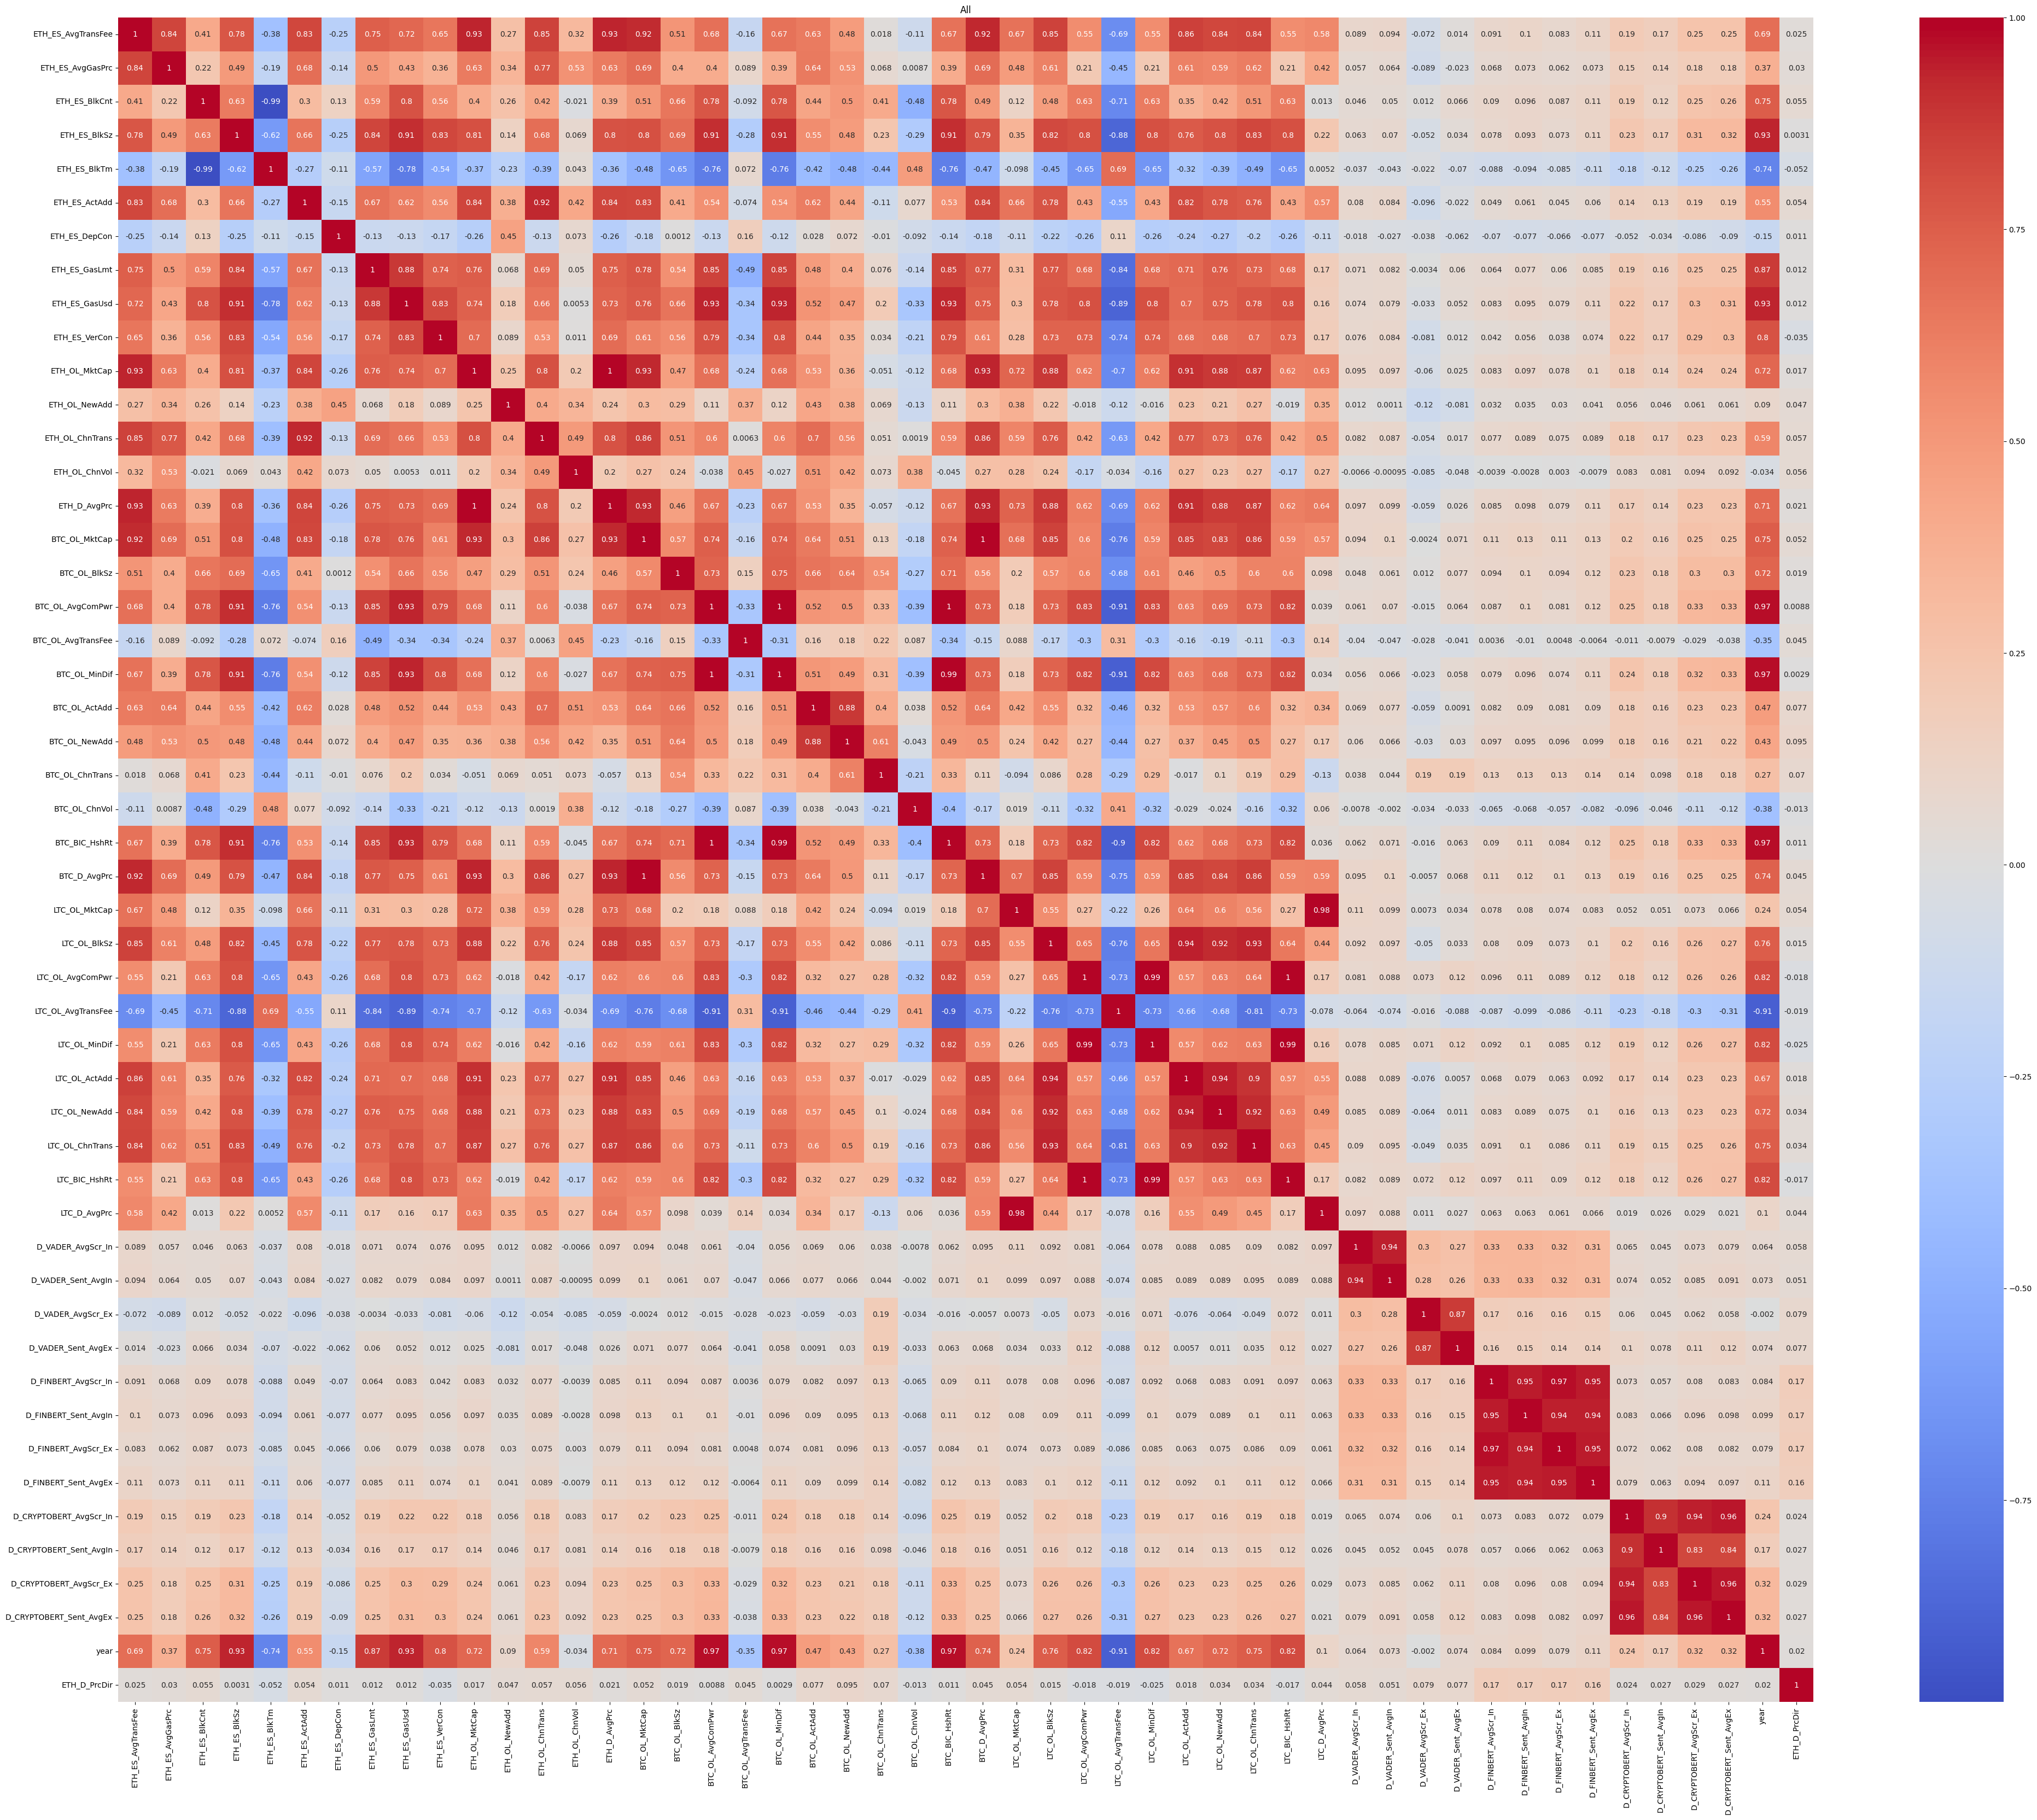

In [242]:
plotter.plot_correlation_matrix(corr, method="spearman",figsize=(50,40), title="All")

In [207]:
plotter.save_graph(filepath=f"{root_dir}\\matrix")

## ARIMA

In [68]:
eth_avgprc = all_data["ETH_D_AvgPrc"]

In [69]:
split_ratio = 0.8
split_index = int(len(eth_avgprc) * split_ratio)
train = eth_avgprc.iloc[:split_index]
test = eth_avgprc.iloc[split_index:]

In [70]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series, alpha=0.05):
    """
    Perform Augmented Dickey-Fuller (ADF) test for stationarity.
    
    :param series: Pandas Series to test.
    :param alpha: Significance level (default 0.05).
    :return: Boolean (True if stationary, False otherwise) and test result dictionary.
    """
    result = adfuller(series)
    p_value = result[1]
    is_stationary = p_value < alpha
    return is_stationary, {"ADF Statistic": result[0], "p-value": p_value, "Critical Values": result[4]}

In [71]:
is_stationary, result = adf_test(train)

In [72]:
is_stationary

False

In [73]:
result

{'ADF Statistic': -1.5111525336660314,
 'p-value': 0.527987302985131,
 'Critical Values': {'1%': -3.433870617038361,
  '5%': -2.863095154794451,
  '10%': -2.567597908717771}}

In [74]:
def difference_until_stationary(series, max_diff=1):
    """
    Apply differencing until the series becomes stationary.
    
    :param series: Pandas Series of time series data.
    :param max_diff: Maximum number of differences to apply.
    :return: Differenced series and number of differences applied.
    """
    diff_series = series.copy()
    d = 0
    for i in range(max_diff):
        # stationary, result = adf_test(diff_series)
        # if stationary:
        #     print(f"Series is stationary after {d} differencing(s).")
        #     return diff_series, d
        diff_series = diff_series.diff().dropna()
    #     d += 1
    # print("Series did not become stationary within max differencing limit.")
    return diff_series, d

In [75]:
diff_series, d = difference_until_stationary(train)

In [76]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

def plot_acf_pacf(series, lags=20):
    """
    Plot ACF and PACF graphs for a given time series.

    :param series: Pandas Series containing time series data.
    :param lags: Number of lags to display in the plots (default is 20).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot ACF (for q selection in ARIMA)
    sm.graphics.tsa.plot_acf(series, lags=lags, ax=axes[0])
    axes[0].set_title("Autocorrelation Function (ACF)")

    # Plot PACF (for p selection in ARIMA)
    sm.graphics.tsa.plot_pacf(series, lags=lags, ax=axes[1])
    axes[1].set_title("Partial Autocorrelation Function (PACF)")

    plt.tight_layout()
    plt.show()

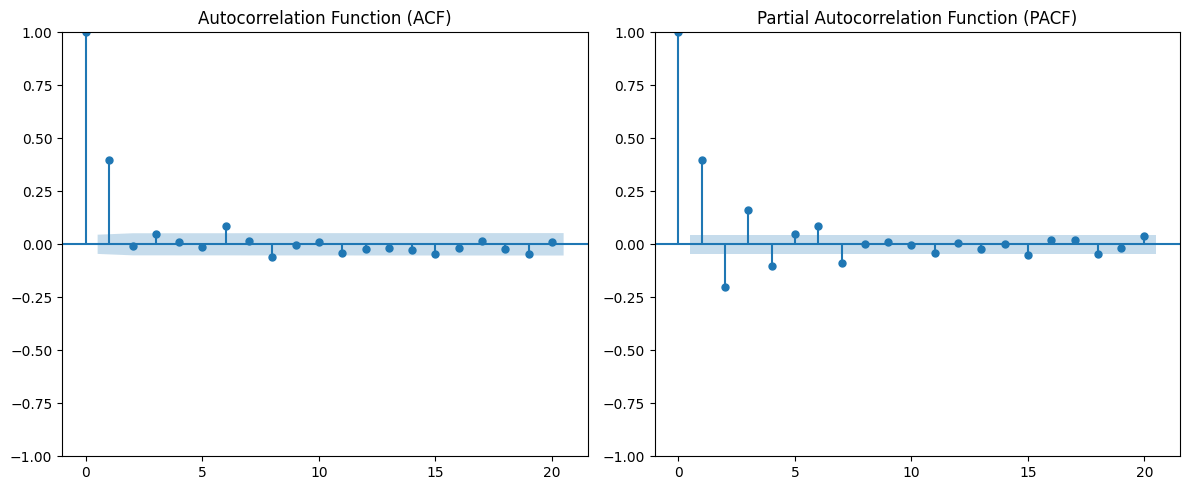

In [77]:
plot_acf_pacf(diff_series)

In [83]:
from statsmodels.tsa.arima.model import ARIMA
# model = ARIMA(endog=train, order=(7,1,1))
# fitted_model = model.fit()

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# warnings.filterwarnings("ignore")

p = range(0, 7)
q = range(0, 8)

best_aic = float("inf")
best_order = None
best_model = None

for p in range(7):
    for q in range(8):
        try:
            model = ARIMA(train, order=(p,1,q))
            results = model.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p,1,q)
                best_model = results
        except:
            continue

print(f"Best SARIMA Order: {best_order}, AIC: {best_aic}")

C:\Users\rajdh\anaconda3\envs\STD_DS_LIB\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajdh\anaconda3\envs\STD_DS_LIB\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajdh\anaconda3\envs\STD_DS_LIB\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajdh\anaconda3\envs\STD_DS_LIB\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajdh\anaconda3\envs\STD_DS_LIB\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Best SARIMA Order: (6, 1, 3), AIC: 19886.92053659558


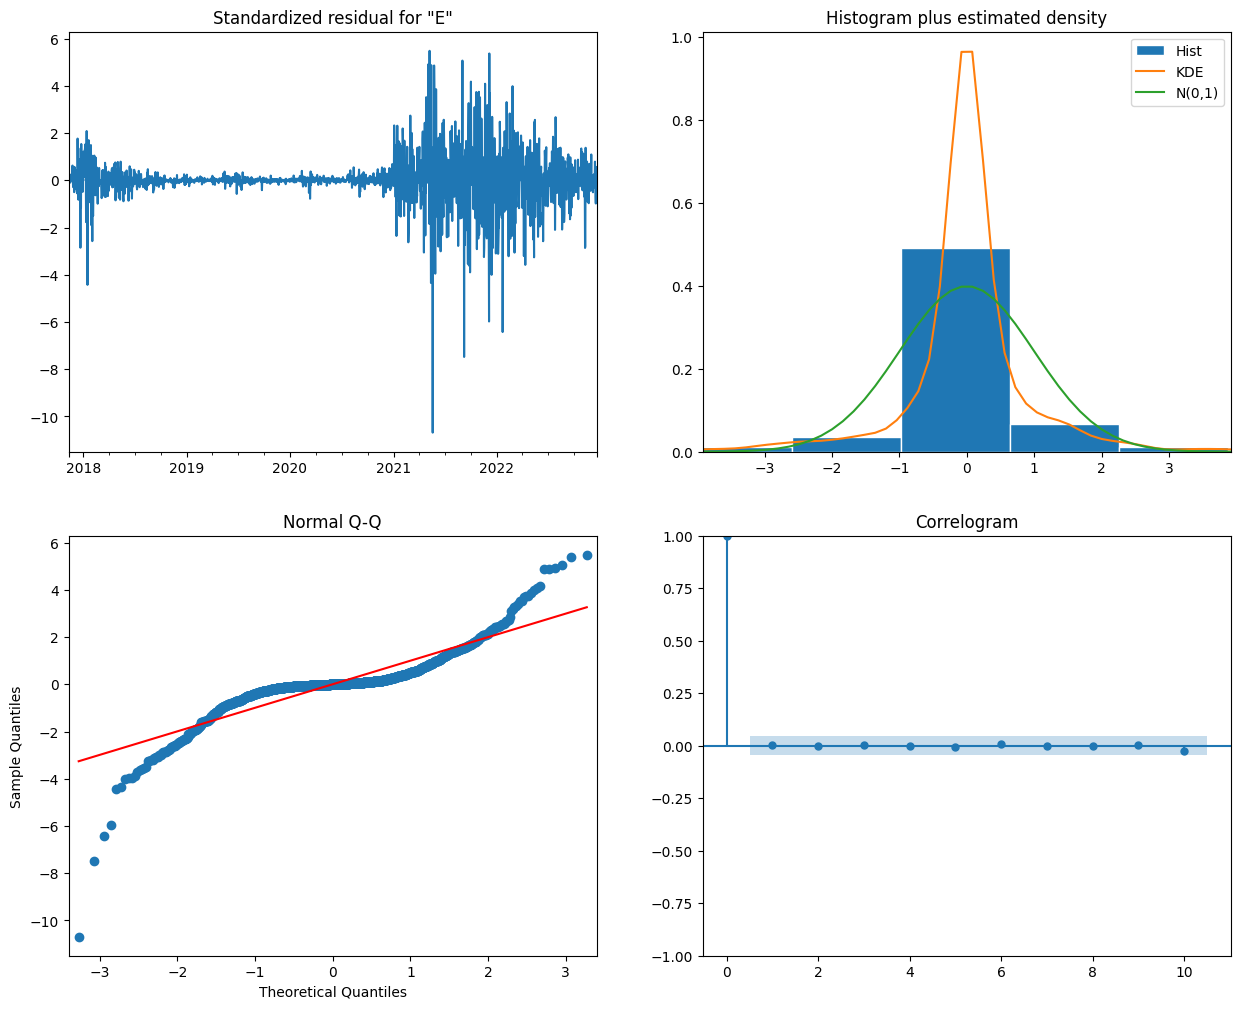

In [84]:
best_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [85]:
best_model.fittedvalues

Date
2017-11-09       0.000000
2017-11-10     316.917837
2017-11-11     306.937594
2017-11-12     308.213615
2017-11-13     310.664613
                 ...     
2022-12-16    1267.383171
2022-12-17    1194.030381
2022-12-18    1168.270021
2022-12-19    1195.567055
2022-12-20    1165.693340
Length: 1868, dtype: float64

In [86]:
forecast = best_model.forecast(steps=len(test))

In [87]:
import matplotlib.pyplot as plt

def plot_arima_forecast(original_series, forecast_series, train_end):
    """
    Plots the original time series along with the ARIMA forecast.

    :param original_series: The actual time series (Pandas Series).
    :param forecast_series: The predicted values from the ARIMA model (Pandas Series).
    :param train_end: The point where training data ends (datetime or index).
    """
    plt.figure(figsize=(12, 6))

    # Plot the original time series
    plt.plot(original_series, label="Actual Data", color="blue")

    # Plot the ARIMA forecast
    plt.plot(forecast_series, label="ARIMA Forecast", color="red")

    # Mark train-test split
    plt.axvline(x=train_end, color='black', linestyle="--", label="Train-Test Split")

    # Labels and legend
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("ARIMA Forecast vs Actual")
    plt.legend()
    plt.grid(True)

    plt.show()

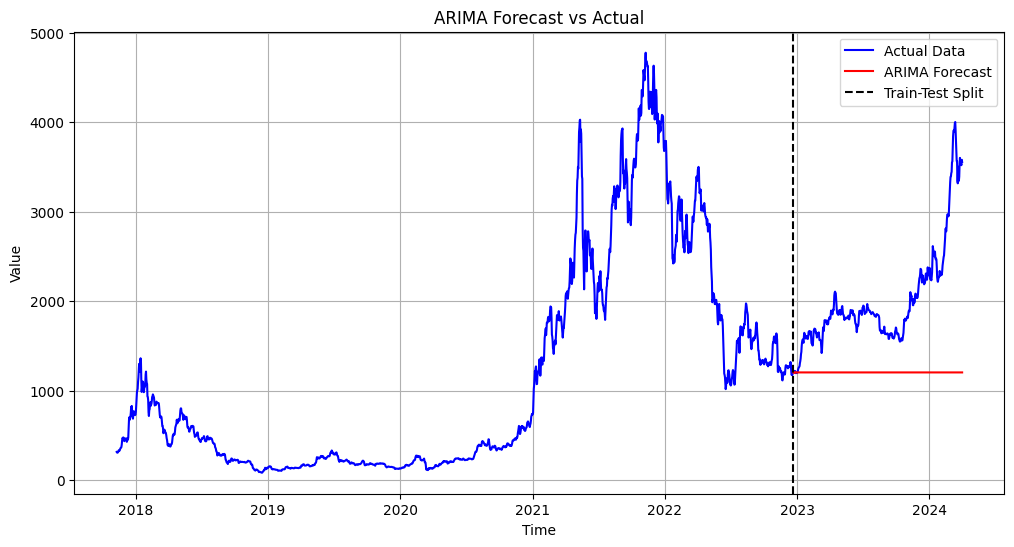

In [88]:
plot_arima_forecast(eth_avgprc, forecast, train.index[-1])

ERROR! Session/line number was not unique in database. History logging moved to new session 355
Completed: 1213.9546813964844
Completed: 1210.2423400878906
Completed: 1220.30810546875
Completed: 1220.6292114257812
Completed: 1216.842742919922
Completed: 1221.8012084960938
Completed: 1219.0231018066406
Completed: 1200.388427734375
Completed: 1196.026824951172
Completed: 1197.5748901367188
Completed: 1198.855926513672
Completed: 1198.509796142578
Completed: 1207.7088623046875
Completed: 1214.0274353027344
Completed: 1237.3053894042969
Completed: 1252.666961669922
Completed: 1258.50146484375
Completed: 1266.639892578125
Completed: 1274.7819213867188
Completed: 1309.4536743164062
Completed: 1329.8164978027344
Completed: 1358.983856201172
Completed: 1408.4983215332031
Completed: 1433.814422607422
Completed: 1504.2157287597656
Completed: 1545.263916015625
Completed: 1563.2415466308594
Completed: 1573.0726013183594
Completed: 1548.6838684082031
Completed: 1535.0391235351562
Completed: 1604.23

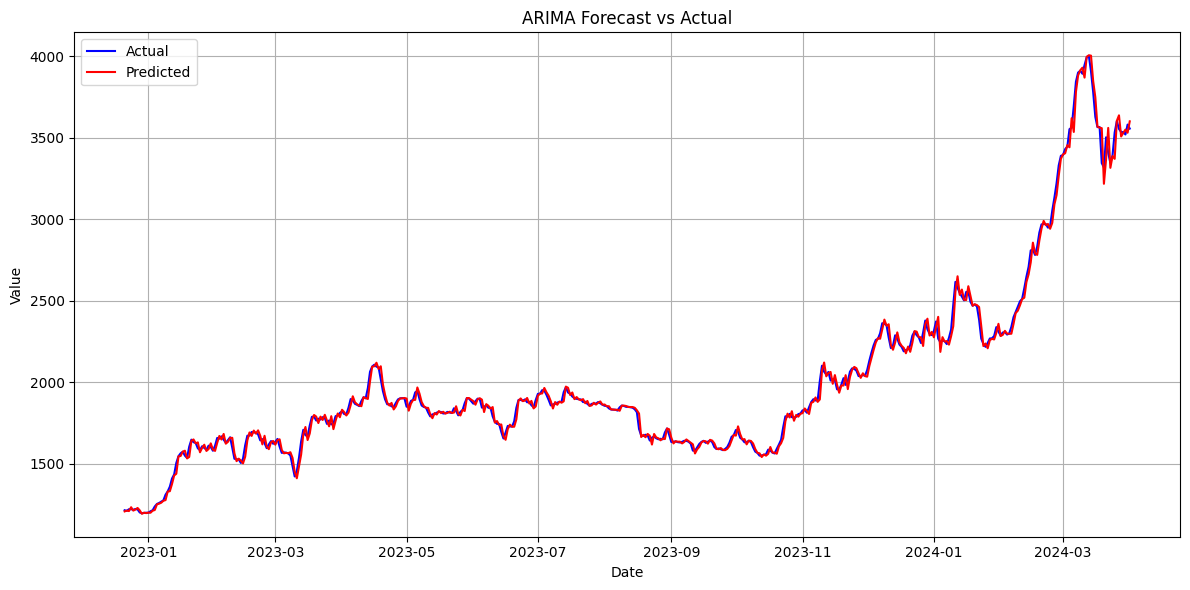

NameError: name 'mean_squared_error' is not defined

In [80]:
# from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import ARIMA
order = (6, 1, 3)

# Store predictions
predictions = []

# Walk-forward forecasting
history = list(train)
for t in range(len(test)):
    model = ARIMA(maxiter=500, order=order)
    model.fit(history)
    forecast = model.predict(n_periods=1)[0]
    predictions.append(forecast)
    history.append(test.iloc[t])
    print(f"Completed: {test[t]}")
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label='Actual', color='blue')
plt.plot(test.index, predictions, label='Predicted', color='red')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'RMSE: {rmse:.4f}')

In [83]:
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(test, predictions)
r2 = r2_score(test, predictions)
print(r2)

0.9959777436217707


In [84]:
print(test)

Date
2022-12-21    1213.954681
2022-12-22    1210.242340
2022-12-23    1220.308105
2022-12-24    1220.629211
2022-12-25    1216.842743
                 ...     
2024-03-28    3534.136902
2024-03-29    3533.061218
2024-03-30    3518.939636
2024-03-31    3579.567444
2024-04-01    3554.918518
Name: ETH_D_AvgPrc, Length: 468, dtype: float64


In [88]:
print(pd.DataFrame(predictions))

               0
0    1206.980612
1    1212.025717
2    1208.962424
3    1232.515243
4    1211.867040
..           ...
463  3506.585227
464  3528.541860
465  3548.661666
466  3529.524871
467  3599.489613

[468 rows x 1 columns]


## Feature engineering

In [236]:
corr.columns
corr.drop(columns=["ETH_ES_BlkCnt", "ETH_ES_BlkTm","ETH_ES_DepCon","ETH_OL_NewAdd","ETH_OL_ChnVol","BTC_OL_BlkSz",
                          "BTC_OL_AvgTransFee","BTC_OL_NewAdd","BTC_OL_ChnTrans","BTC_OL_ChnVol"], inplace=True)
lag_1_fea = corr.shift(1)
lag_3_fea = corr.shift(3)
lag_5_fea = corr.shift(5)
lag_7_fea = corr.shift(7)

In [237]:
lag_1_fea["ETH_D_AvgPrc"]=all_data["ETH_D_AvgPrc"]
lag_1_fea["ETH_D_PrcDir"]=all_data["ETH_D_PrcDir"]
lag_1_fea = lag_1_fea.dropna()
lag_3_fea["ETH_D_AvgPrc"]=all_data["ETH_D_AvgPrc"]
lag_3_fea["ETH_D_PrcDir"]=all_data["ETH_D_PrcDir"]
lag_3_fea = lag_3_fea.dropna()
lag_5_fea["ETH_D_AvgPrc"]=all_data["ETH_D_AvgPrc"]
lag_5_fea["ETH_D_PrcDir"]=all_data["ETH_D_PrcDir"]
lag_5_fea = lag_5_fea.dropna()
lag_7_fea["ETH_D_AvgPrc"]=all_data["ETH_D_AvgPrc"]
lag_7_fea["ETH_D_PrcDir"]=all_data["ETH_D_PrcDir"]
lag_7_fea = lag_7_fea.dropna()

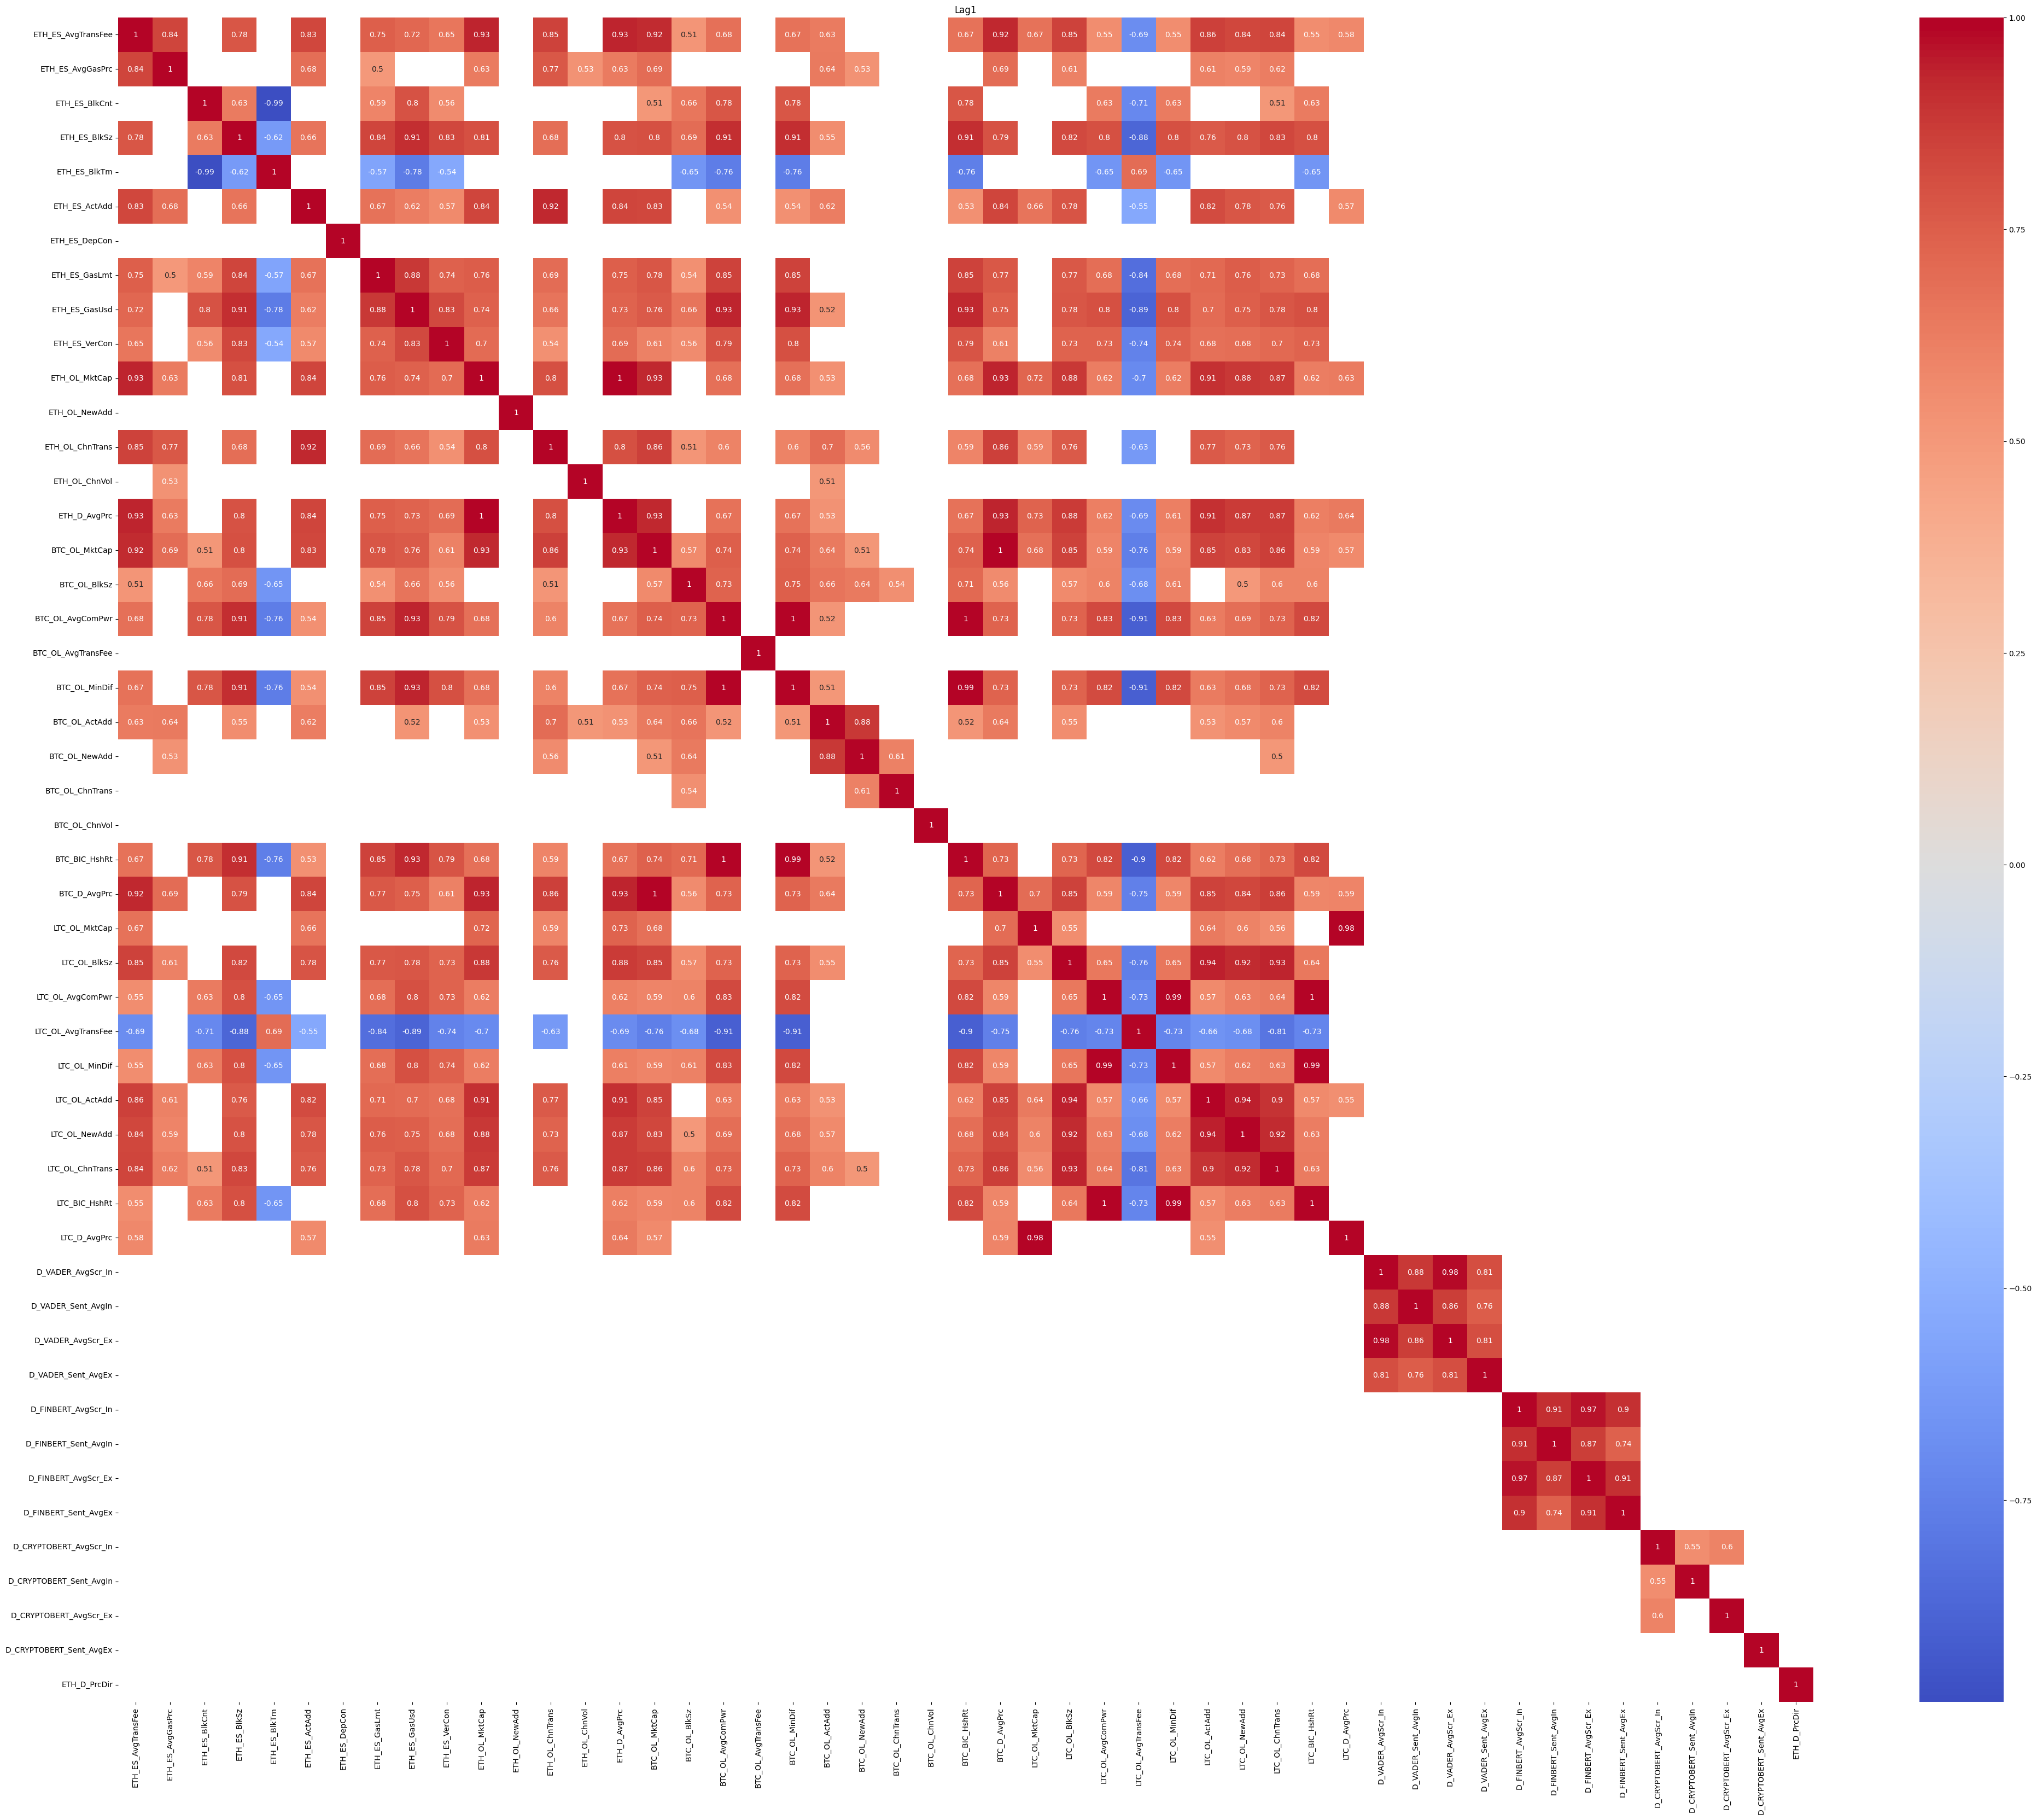

In [219]:
plotter.plot_correlation_matrix(lag_1_fea, method="spearman", figsize=(50,40), title="Lag1", mask=True, threshold=0.5)
plotter.save_graph()

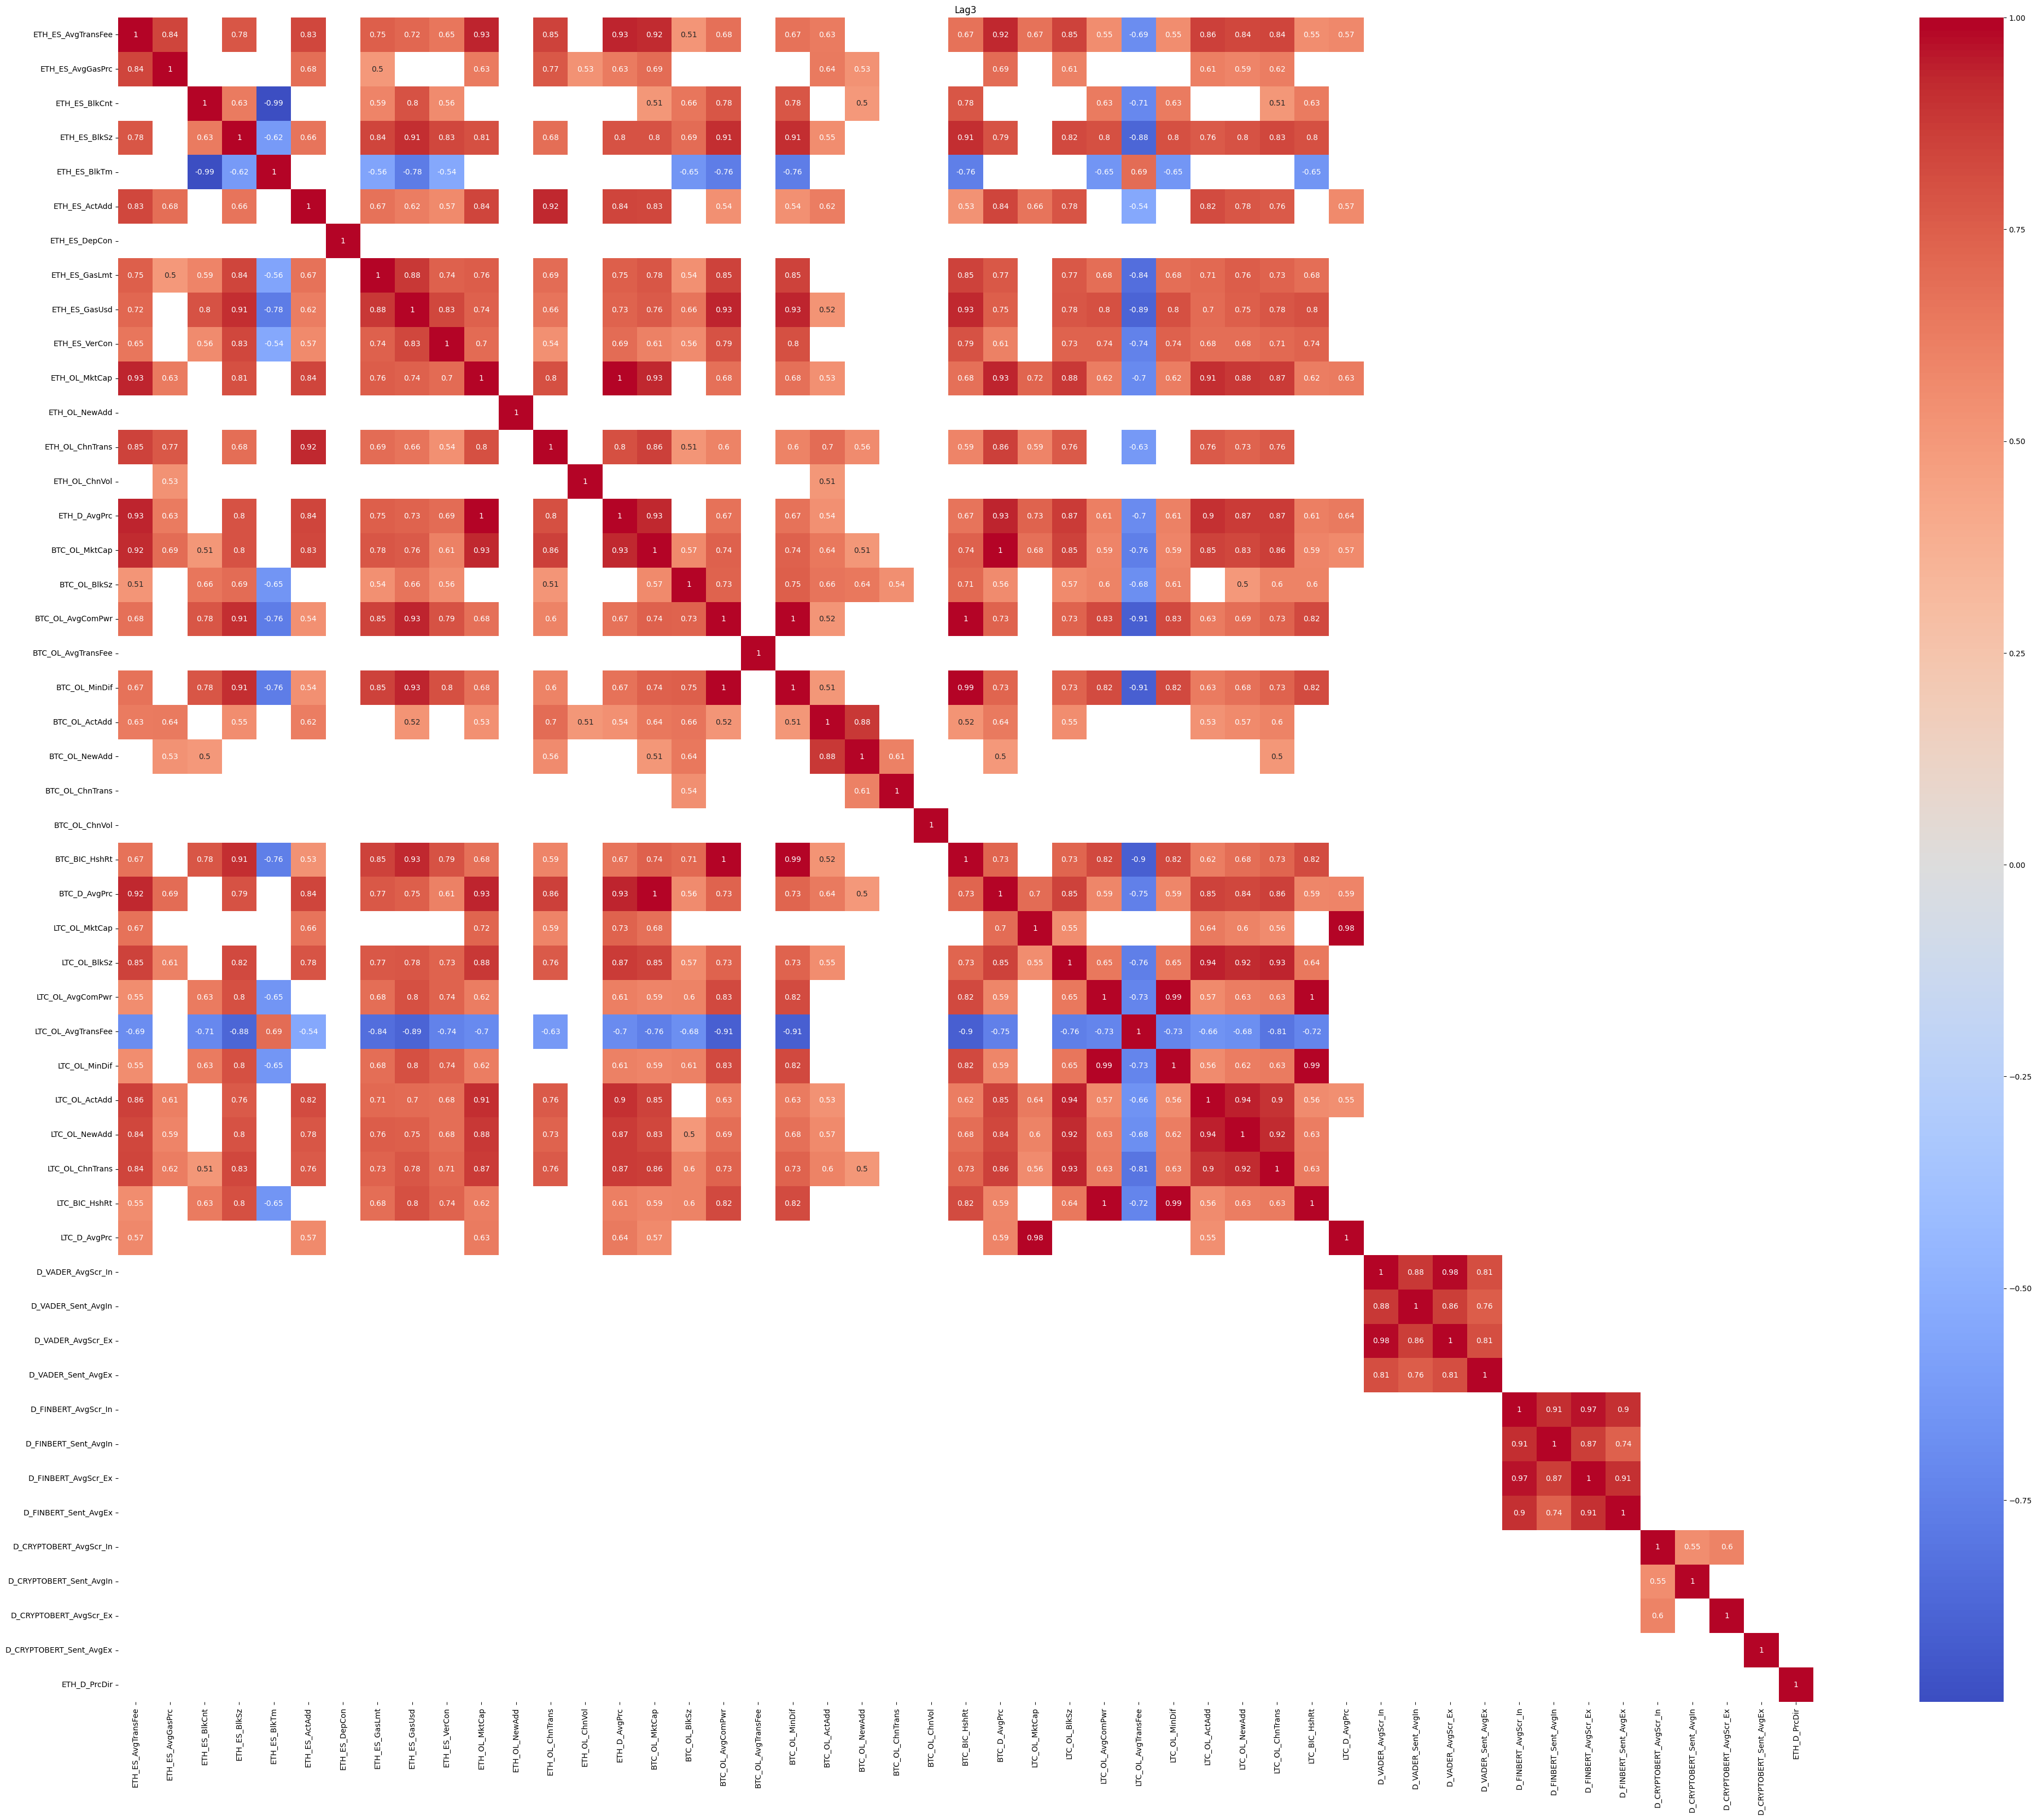

In [220]:
plotter.plot_correlation_matrix(lag_3_fea, method="spearman", mask=True, threshold=0.5, figsize=(50,40), title="Lag3")
# plotter.save_graph()

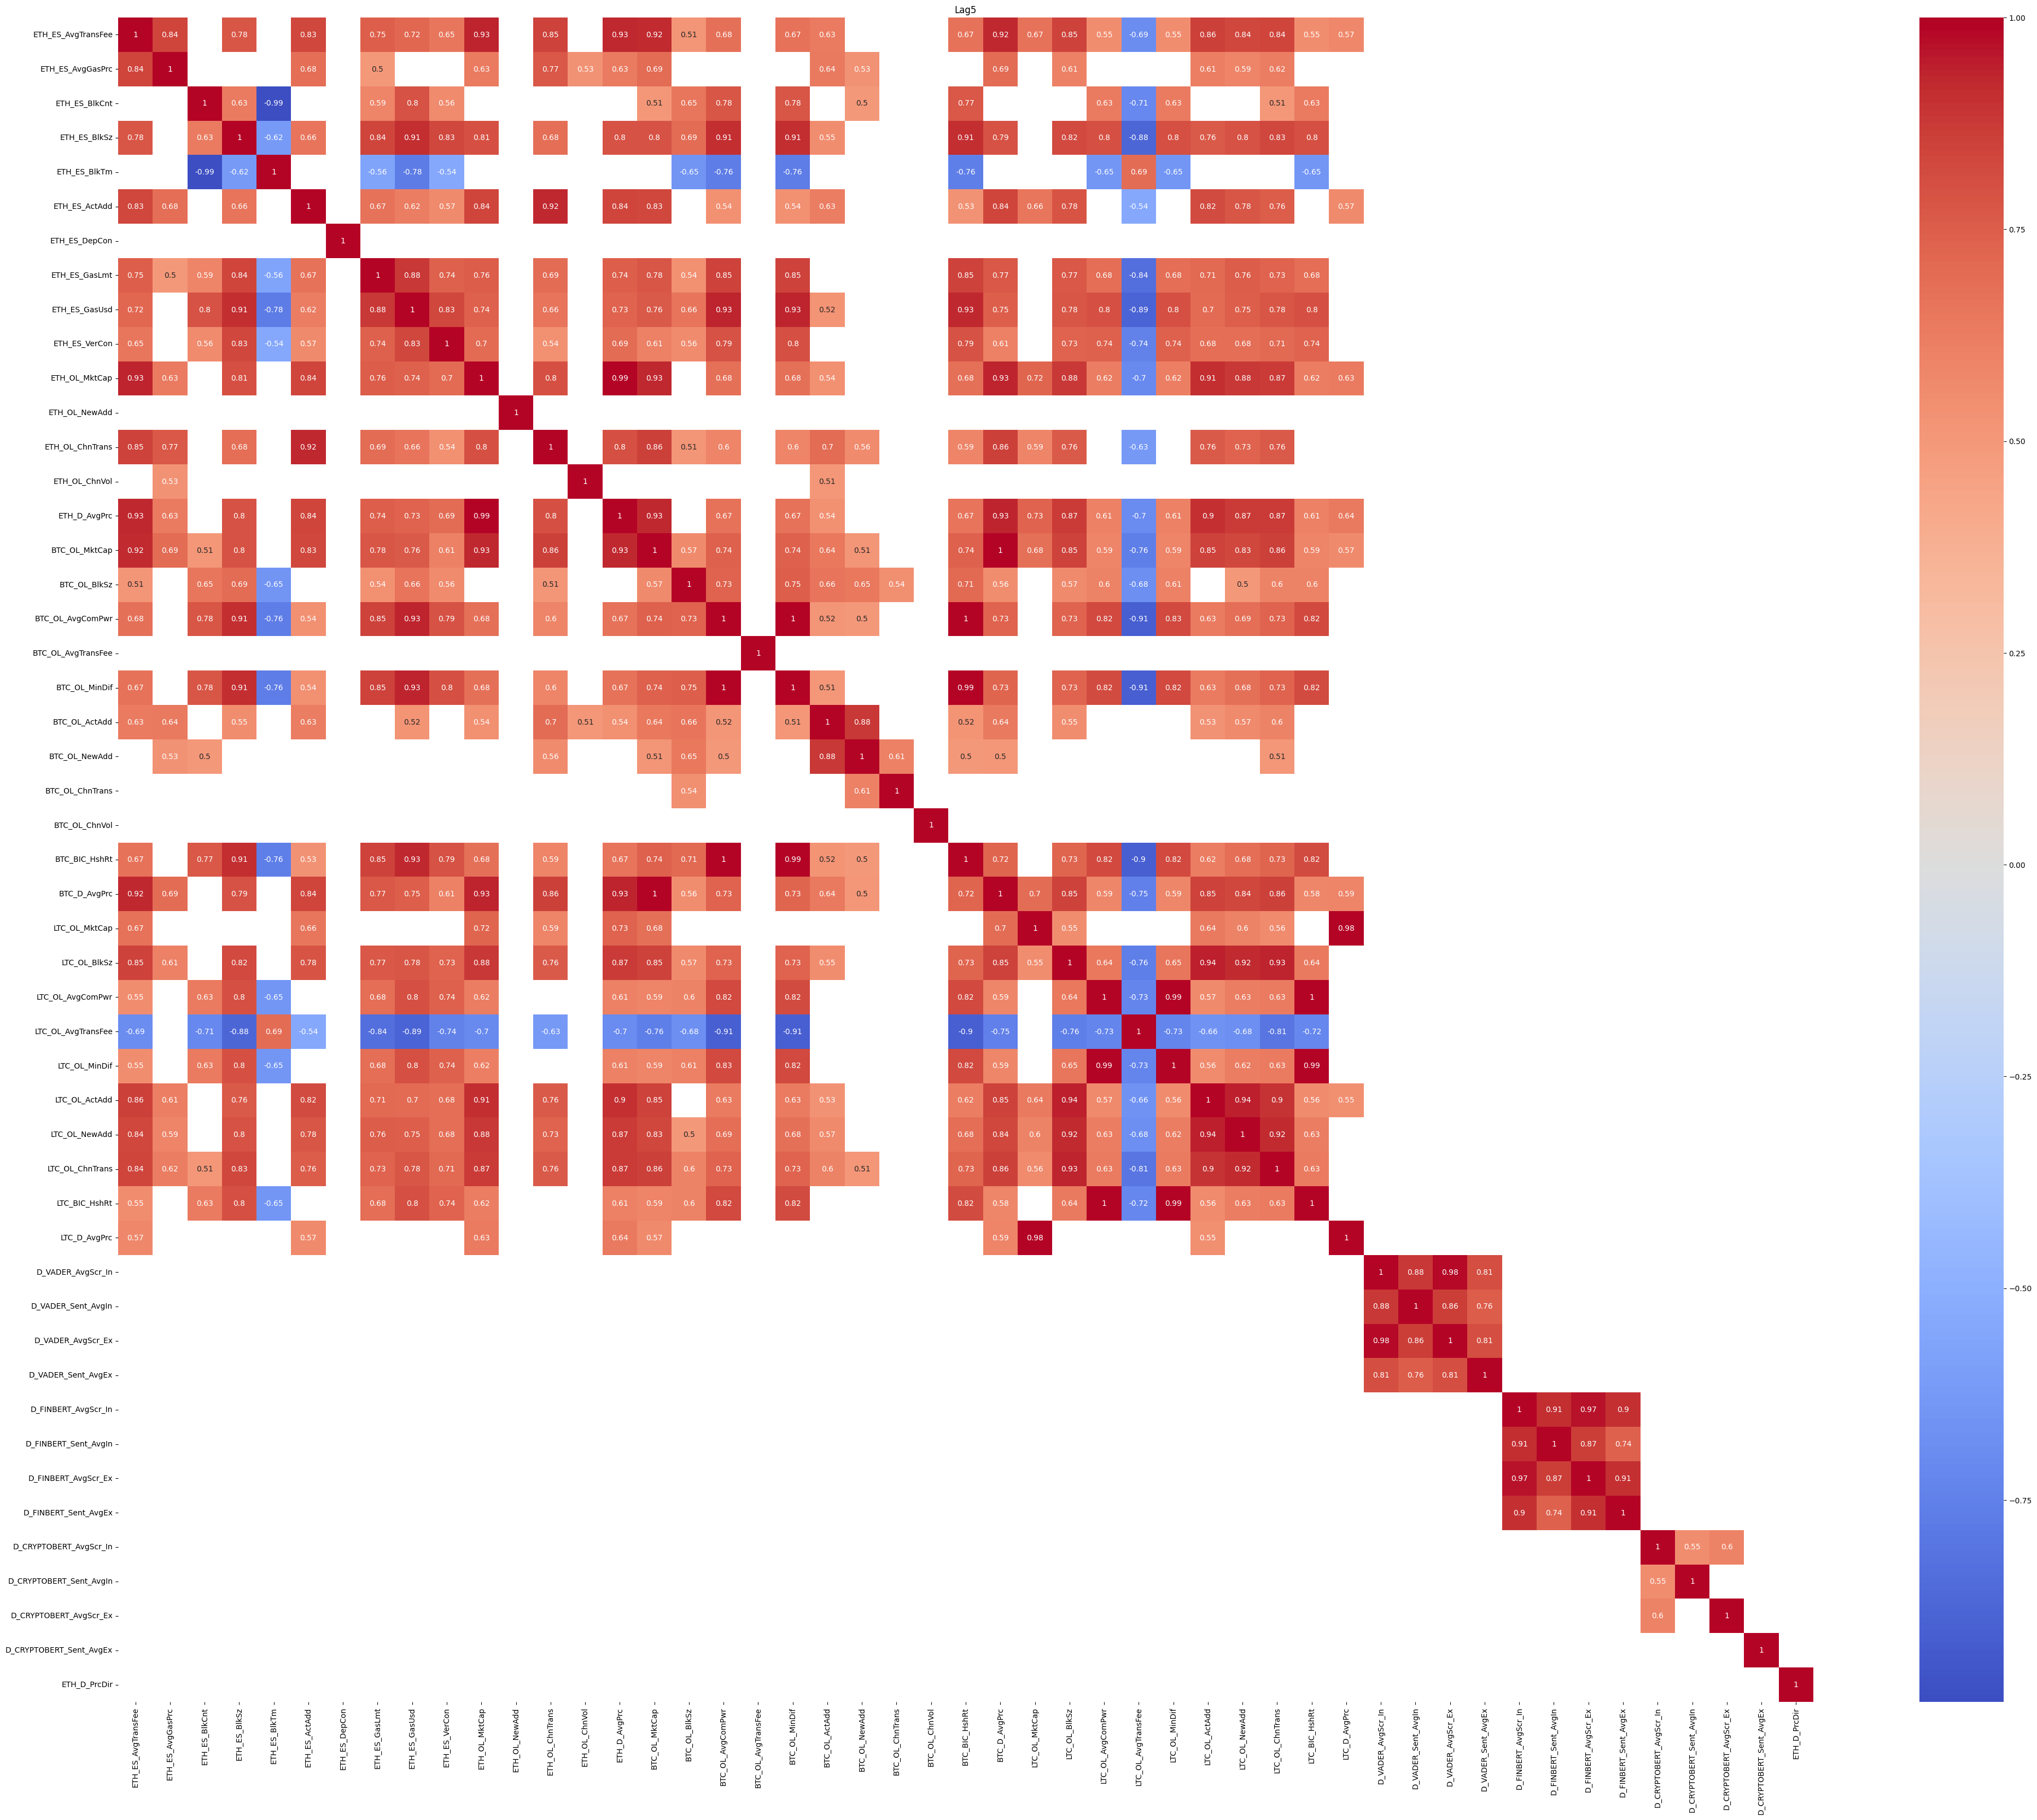

In [221]:
plotter.plot_correlation_matrix(lag_5_fea, method="spearman", mask=True, threshold=0.5, figsize=(50,40), title="Lag5")
# plotter.save_graph()

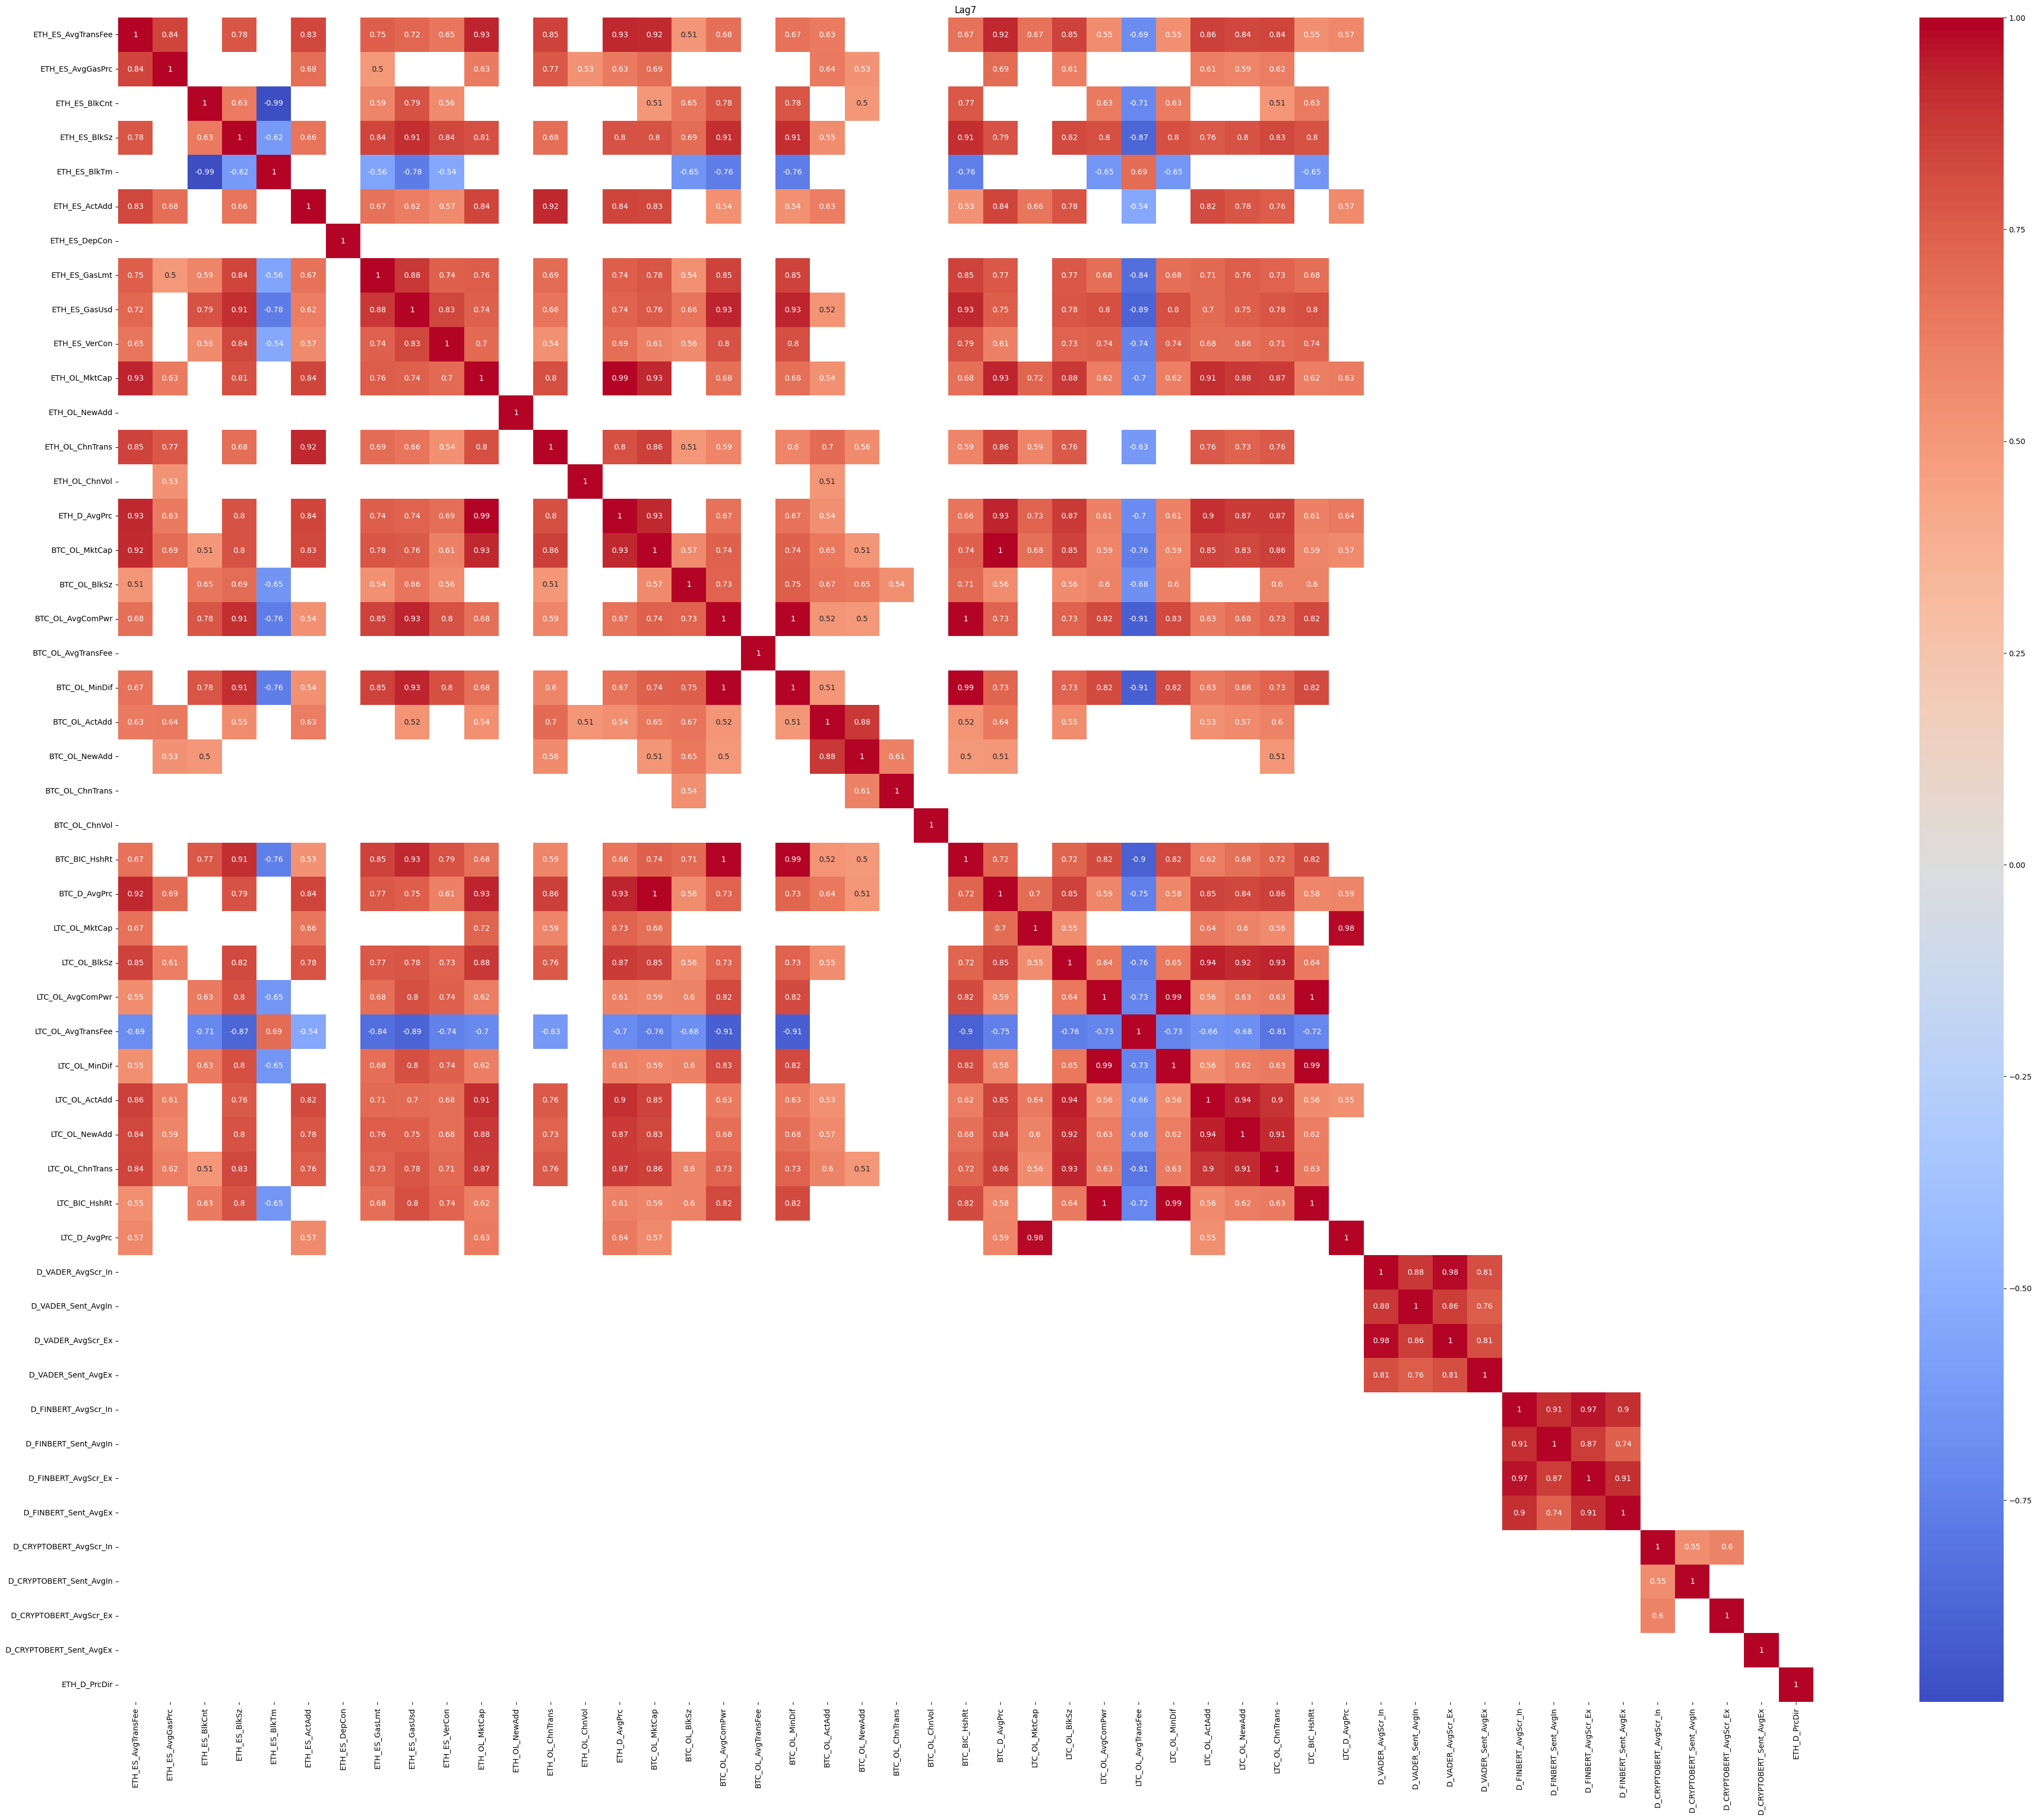

In [222]:
plotter.plot_correlation_matrix(lag_7_fea, method="spearman", mask=True, threshold=0.5, figsize=(50,40), title="Lag7")
# plotter.save_graph()

In [223]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

def make_stationary(df, significance=0.05, max_diffs=5):
    """
    Iterates through each column in a DataFrame and differences it until it becomes stationary
    based on the Augmented Dickey-Fuller (ADF) test.
    
    Parameters:
    - df: Pandas DataFrame with time series data.
    - significance: Significance level for the ADF test (default 0.05).
    - max_diffs: Maximum number of differences to apply (default 5).
    
    Returns:
    - A new DataFrame with differenced values.
    - A dictionary mapping column names to the number of differences applied.
    """
    stationary_df = df.copy()
    diff_counts = {}  # Store number of differences applied per column
    
    for col in df.columns:
        series = df[col].dropna()  # Drop NaNs before testing
        diff_count = 0
        
        # Perform differencing until stationary or max_diffs reached
        while diff_count < max_diffs:
            adf_test = adfuller(series)
            p_value = adf_test[1]
            
            if p_value < significance:
                break  # Stop if stationary
            
            series = series.diff().dropna()  # Apply differencing
            diff_count += 1
        
        stationary_df[col] = series  # Store transformed series
        diff_counts[col] = diff_count
    
    return stationary_df, diff_counts

In [224]:
corr_stat, diff_counts = make_stationary(corr)

In [235]:
diff_counts

{'ETH_ES_AvgTransFee': 1,
 'ETH_ES_AvgGasPrc': 0,
 'ETH_ES_BlkCnt': 1,
 'ETH_ES_BlkSz': 1,
 'ETH_ES_BlkTm': 0,
 'ETH_ES_ActAdd': 1,
 'ETH_ES_DepCon': 0,
 'ETH_ES_GasLmt': 1,
 'ETH_ES_GasUsd': 1,
 'ETH_ES_VerCon': 1,
 'ETH_OL_MktCap': 1,
 'ETH_OL_NewAdd': 0,
 'ETH_OL_ChnTrans': 1,
 'ETH_OL_ChnVol': 0,
 'ETH_D_AvgPrc': 1,
 'BTC_OL_MktCap': 1,
 'BTC_OL_BlkSz': 1,
 'BTC_OL_AvgComPwr': 1,
 'BTC_OL_AvgTransFee': 0,
 'BTC_OL_MinDif': 1,
 'BTC_OL_ActAdd': 1,
 'BTC_OL_NewAdd': 0,
 'BTC_OL_ChnTrans': 1,
 'BTC_OL_ChnVol': 0,
 'BTC_BIC_HshRt': 1,
 'BTC_D_AvgPrc': 1,
 'LTC_OL_MktCap': 0,
 'LTC_OL_BlkSz': 0,
 'LTC_OL_AvgComPwr': 1,
 'LTC_OL_AvgTransFee': 0,
 'LTC_OL_MinDif': 1,
 'LTC_OL_ActAdd': 1,
 'LTC_OL_NewAdd': 0,
 'LTC_OL_ChnTrans': 0,
 'LTC_BIC_HshRt': 1,
 'LTC_D_AvgPrc': 0,
 'D_VADER_AvgScr_In': 0,
 'D_VADER_Sent_AvgIn': 0,
 'D_VADER_AvgScr_Ex': 0,
 'D_VADER_Sent_AvgEx': 0,
 'D_FINBERT_AvgScr_In': 0,
 'D_FINBERT_Sent_AvgIn': 0,
 'D_FINBERT_AvgScr_Ex': 0,
 'D_FINBERT_Sent_AvgEx': 0,
 'D_CRYPT

In [225]:
corr_stat.dropna(inplace=True)

In [226]:
from statsmodels.tsa.stattools import grangercausalitytests
def grangers_causality(df, target_col, max_lag=5, significance=0.05):
    """
    Perform Granger's Causality test for each column in a DataFrame against a specified target column.
    
    Parameters:
    - df: Pandas DataFrame with time series data (50 features + target column).
    - target_col: The column name of the target variable.
    - max_lag: Maximum lag to test (default 5).
    - significance: Significance level for the test (default 0.05).
    
    Returns:
    - A dictionary where keys are feature column names and values are lists containing whether they Granger-cause the target variable and the significant lag values.
    """
    results = {}
    for col in df.columns:
        if col == target_col:
            continue  # Skip the target column itself
        
        test_result = grangercausalitytests(df[[target_col, col]].dropna(), max_lag, verbose=False)
        
        # Extract p-values across lags
        p_values = {lag: test_result[lag][0]['ssr_chi2test'][1] for lag in range(1, max_lag + 1)}
        
        # Identify significant lags
        significant_lags = [lag for lag, p in p_values.items() if p < significance]
        
        # Determine if the feature Granger-causes the target
        results[col] = [len(significant_lags) > 0, significant_lags]
    
    return results

In [227]:
granger_results = grangers_causality(corr_stat, max_lag=7, target_col='ETH_D_AvgPrc')

In [228]:
granger_results

{'ETH_ES_AvgTransFee': [True, [3, 4, 5, 6, 7]],
 'ETH_ES_AvgGasPrc': [False, []],
 'ETH_ES_BlkCnt': [False, []],
 'ETH_ES_BlkSz': [False, []],
 'ETH_ES_BlkTm': [False, []],
 'ETH_ES_ActAdd': [False, []],
 'ETH_ES_DepCon': [False, []],
 'ETH_ES_GasLmt': [True, [1, 2, 3, 4, 5, 7]],
 'ETH_ES_GasUsd': [False, []],
 'ETH_ES_VerCon': [False, []],
 'ETH_OL_MktCap': [True, [1, 2, 3, 4, 5, 6, 7]],
 'ETH_OL_NewAdd': [False, []],
 'ETH_OL_ChnTrans': [True, [7]],
 'ETH_OL_ChnVol': [True, [1, 2, 3, 4, 6, 7]],
 'BTC_OL_MktCap': [True, [1, 2, 4, 5, 6, 7]],
 'BTC_OL_BlkSz': [False, []],
 'BTC_OL_AvgComPwr': [False, []],
 'BTC_OL_AvgTransFee': [False, []],
 'BTC_OL_MinDif': [True, [3, 4, 6, 7]],
 'BTC_OL_ActAdd': [True, [6, 7]],
 'BTC_OL_NewAdd': [False, []],
 'BTC_OL_ChnTrans': [False, []],
 'BTC_OL_ChnVol': [True, [2, 3, 6, 7]],
 'BTC_BIC_HshRt': [False, []],
 'BTC_D_AvgPrc': [True, [1, 2]],
 'LTC_OL_MktCap': [True, [4, 5, 6, 7]],
 'LTC_OL_BlkSz': [True, [4]],
 'LTC_OL_AvgComPwr': [False, []],
 'LTC_

In [252]:
data = pd.read_csv(f"{get_root_directory()}\\data\\raw\\ETH_data\\ETH-USD_price_data.csv")

In [255]:
date_format = "%d/%m/%Y"
print(data.columns)
data["Date"] = pd.to_datetime(data["Date"])

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [256]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984
1,2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984
2,2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992
3,2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936
4,2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984
...,...,...,...,...,...,...,...
2462,2024-08-06,2417.269775,2553.581055,2416.527100,2458.723877,2458.723877,26041995921
2463,2024-08-07,2458.989014,2551.560791,2312.168701,2336.589355,2336.589355,24264218606
2464,2024-08-08,2336.915039,2721.954590,2322.529541,2683.352783,2683.352783,23468291180
2465,2024-08-09,2683.719971,2706.451172,2555.229492,2599.598633,2599.598633,17907141655
